In [1]:
import os
from importlib import reload
import sys
sys.path.insert(
    0, r'C:\Users\richa\GitHub\py_neuromodulation\pyneuromodulation')

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from pybv import write_brainvision
import mne
import mne_bids

import start_BIDS
import define_M1
import nm_reader as NM_reader


def get_all_files(path, suffix, get_bids=False, prefix=None, bids_root=None,
                  verbose=False, extension=None):
    """Return all files in all (sub-)directories of path with given suffixes and prefixes (case-insensitive).

    Args:
        path (string)
        suffix (iterable): e.g. ["vhdr", "edf"] or ".json"
        get_bids (boolean): True if BIDS_Path type should be returned instead of string. Default: False
        bids_root (string/path): Path of BIDS root folder. Only required if get_bids=True.
        prefix (iterable): e.g. ["SelfpacedRota", "ButtonPress] (optional)

    Returns:
        filepaths (list of strings or list of BIDS_Path)
    """

    if isinstance(suffix, str):
        suffix = [suffix]
    if isinstance(prefix, str):
        prefix = [prefix]

    filepaths = []
    for root, dirs, files in os.walk(path):
        for file in files:
            for suff in suffix:
                if file.endswith(suff.lower()):
                    if not prefix:
                        filepaths.append(os.path.join(root, file))
                    else:
                        for pref in prefix:
                            if pref.lower() in file.lower():
                                filepaths.append(os.path.join(root, file))

    bids_paths = filepaths
    if get_bids:
        if not bids_root:
            print(
                "Warning: No root folder given. Please pass bids_root parameter to create a complete BIDS_Path object.")
        bids_paths = []
        for filepath in filepaths:
            entities = mne_bids.get_entities_from_fname(filepath)
            try:
                bids_path = mne_bids.BIDSPath(subject=entities["subject"],
                                              session=entities["session"],
                                              task=entities["task"],
                                              run=entities["run"],
                                              acquisition=entities[
                                                  "acquisition"],
                                              suffix=entities["suffix"],
                                              extension=extension,
                                              root=bids_root)
            except ValueError as err:
                print(
                    f"ValueError while creating BIDS_Path object for file {filepath}: {err}")
            else:
                bids_paths.append(bids_path)

    if verbose:
        if not bids_paths:
            print("No corresponding files found.")
        else:
            print('Corresponding files found:')
            for idx, file in enumerate(bids_paths):
                print(idx, ':', os.path.basename(file))

    return bids_paths

In [2]:
deriv_root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm'

files = get_all_files(
    path=deriv_root,
    suffix='.csv',
    get_bids=False,
    prefix="features",
    bids_root=deriv_root,
    verbose=True,
    extension=None)

Corresponding files found:
0 : sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_FEATURES.csv
1 : sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_FEATURES.csv
2 : sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_FEATURES.csv
3 : sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg_FEATURES.csv
4 : sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_FEATURES.csv
5 : sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_FEATURES.csv
6 : sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg_FEATURES.csv
7 : sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_FEATURES.csv
8 : sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg_FEATURES.csv
9 : sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_FEATURES.csv
10 : sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_

In [3]:
def run_example_read_features(feature_file, ch_name, label):
    """"""
    settings = nm_reader.read_settings(feature_file)

    # read run_analysis
    run_analyzer = nm_reader.read_run_analyzer()

    # optionally read ML estimations
    ML_est = nm_reader.read_ML_estimations()

    df_ = nm_reader.read_M1(feature_file)
    features_ = nm_reader.read_features(feature_file)

    channels = np.array(settings['ch_names'])
    label_name = [ch for ch in channels if label in ch]
    dat_label = nm_reader.read_label(label_name[0])
    nm_reader.label = stats.zscore(dat_label)

    # Fist case: filter for bandpass activity features only
    dat_ch = nm_reader.read_channel_data(ch_name, read_bp_activity_only=True)

    # estimating epochs, with shape (epochs,samples,channels,features)
    X_epoch, y_epoch = nm_reader.get_epochs_ch(
        epoch_len=6, sfreq=settings["sampling_rate_features"], threshold=0.1)
   # print("Plotting feature covariance matrix.")
    #nm_reader.plot_corr_matrix(feature_file, feature_str_add="bandpass")
    print("Plotting feature target averaged.")
    nm_reader.plot_epochs_avg(feature_file, feature_str_add="bandpass")

In [4]:
import seaborn as sb
from scipy import stats, signal

from numba import njit

from sklearn.model_selection import (cross_val_score, train_test_split, 
                                     cross_validate, KFold, StratifiedKFold, 
                                     GroupKFold, GroupShuffleSplit)
from sklearn.kernel_approximation import Nystroem
from sklearn.svm import LinearSVC, SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (f1_score, confusion_matrix, average_precision_score, 
                             auc, precision_recall_curve, plot_precision_recall_curve)

@njit
def getindexlower(array, item):
    for idx, val in np.ndenumerate(array):
        if val <= item:
            return idx

def motint_permut(X, y, list_evs, ind_evs, t_p, item, itemnum):
    """
    """
    print('X.shape: ', X.shape)
    print('Skewedness: ', np.mean(y))
    
    sfreq = 100
    cor_ev = events_arr[:,0]
    
    # Epoch length in sec
    l_ep = 4    
    # Calculate sampling corrected time factor for plotting 
    fac = int(sfreq*l_ep/2)
    # y value correction for plotting
    M = (ml_zs_r[0][:]+0.1)*0.3
    
    aucnprs = []


    #X_ind = np.arange(0,len(list_evs))
    kf = KFold(n_splits=5)
    for train, test in kf.split(list_evs):
        ind_tr = np.isin(ind_evs, train)
        ind_te = np.isin(ind_evs, test)
        X_train = Xm[ind_tr]
        X_test = Xm[ind_te]
        y_train = y[ind_tr]
        y_test = y[ind_te]

        clf = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')

        # Make predictions using the testing set
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        y_pred_all = clf.predict(Xi)

        y_score = clf.decision_function(X_test)
        precision, recall, thresh = precision_recall_curve(y_test, y_score)
        aucpr = auc(recall,precision)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        # calculate skewedness
        ratio = sum((tp,fn)) / sum((tn, tp, fn, fp))
        #print('Ratio: ',ratio)
        aucpr_min = 1 + (1-ratio)*np.log(1-ratio)/ratio
        # AUCPR_max is 1 for AUCPR over recall in [0,1]
        aucpr_max = 1
        # For AUCNPR see: arXiv:1206.4667v2
        aucnpr = (aucpr-aucpr_min)/(aucpr_max-aucpr_min)
        aucnprs.append(aucnpr)

        # Classification signal smoothed over X 'secs'
        smooth = 0.5
        samples = int(sfreq*smooth)
        y_smoothpred = np.empty_like(y_pred_all)
        for s in range(0,len(y_pred_all)):
            if s < samples:
                y_smoothpred[s] = 0
            else:
                y_smoothpred[s] = np.mean(y_pred_all[s-samples:s])   

        # Predictions threshold
        thresh = 0.5
        y_decision = np.empty_like(y_smoothpred)
        for s in range(0,len(y_smoothpred)):
            if y_smoothpred[s] >= thresh:
                y_decision[s] = 1
            else:
                y_decision[s] = 0


        for t in test:
            i = list_evs[t]
            try:
                pred_concat
            except NameError:
                pred_concat = y_pred_all[(cor_ev[i]-fac):(cor_ev[i]+fac)]
                smooth_concat = y_smoothpred[(cor_ev[i]-fac):(cor_ev[i]+fac)]
                decision_concat = y_decision[(cor_ev[i]-fac):(cor_ev[i]+fac)]
                mov_concat = M[(cor_ev[i]-fac):(cor_ev[i]+fac)]
            else:
                pred = y_pred_all[(cor_ev[i]-fac):(cor_ev[i]+fac)]
                smooth = y_smoothpred[(cor_ev[i]-fac):(cor_ev[i]+fac)]
                decision = y_decision[(cor_ev[i]-fac):(cor_ev[i]+fac)]
                mov = M[(cor_ev[i]-fac):(cor_ev[i]+fac)]
                pred_concat = np.vstack((pred_concat, pred))
                smooth_concat = np.vstack((smooth_concat, smooth))
                decision_concat = np.vstack((decision_concat, decision))
                mov_concat = np.vstack((mov_concat, mov))

    decision_arr = pred_concat
    baseline = np.zeros_like(decision_arr[:,0])
    gTs = np.zeros_like(decision_arr[0,:])
    p_vals = np.zeros_like(decision_arr[0,:])
    for i in np.arange(0,len(decision_arr[0,:]),10):
        gT, p_val = permutationTest(decision_arr[:,i], baseline, plot_=False, x_unit='Time', p=100)
        gTs[i:i+10] = gT
        p_vals[i:i+10] = p_val

    decision_arr = decision_concat
    baseline = np.zeros_like(decision_arr[:,0])
    gTs2 = np.zeros_like(decision_arr[0,:])
    p_vals2 = np.zeros_like(decision_arr[0,:])
    for i in np.arange(0,len(decision_arr[0,:]),10):
        gT, p_val = permutationTest(decision_arr[:,i], baseline, plot_=False, x_unit='Time', p=100)
        gTs2[i:i+10] = gT
        p_vals2[i:i+10] = p_val


    sign = 0.01
    ind_sign = getindexlower(p_vals, sign)
    ind_sign2 = getindexlower(p_vals2, sign)

        # Now plot
    num_ep = len(pred_concat)
    plot_all = True
    if plot_all == True:
        p_a = 1
    else:
        p_a = test_size
        
    ep_min = int(num_ep-p_a*num_ep)
    
    m_aucnprs = round(np.mean(aucnprs),2)
    std_aucnprs = round(np.std(aucnprs),2)
    print('Mean AUCNPR: ', m_aucnprs)
    name = 'Label: ' + str(t_p[0]) + 's to ' + str(t_p[1]) +  ' - ' + item + ' - AUCNPR: ' + str(m_aucnprs) + u"\u00B1" + str(std_aucnprs)

    plt.style.use('dark_background')
    plt.figure(dpi=300, figsize=(7,5))
    xlab = np.round(np.arange(-l_ep/2, l_ep/2, 1),2)
    plt.title(name)
    plt.plot(pred_concat[:].mean(axis=0), label='Classification')
    plt.plot(smooth_concat[:].mean(axis=0),label='Smoothed Classif.')
    plt.plot(decision_concat[:].mean(axis=0), label='Prediction')
    plt.plot(mov_concat.mean(axis=0), label='Rotameter')
    plt.plot(p_vals, label='p-value [Classif.]') 
    if ind_sign == None or ind_sign2 == None:
        pass
    else:   
        plt.axvline(ind_sign, label='p < 0.01 [Classif.]')
        plt.axvline(ind_sign2, label='p < 0.01 [Prediction]', color='m')
        #plt.fill_between(np.arange(epoch_pr.shape[1]), epoch_pr.mean(axis=0)-epoch_pr.std(axis=0), \
         #           epoch_pr.mean(axis=0)+epoch_pr.std(axis=0), alpha=0.5, color='r')
    plt.xticks(np.arange(0,l_ep*sfreq, sfreq), xlab)
    plt.xlabel('Time [s]')
    plt.legend(loc='upper left')
    plt.xlim(0*sfreq, l_ep*sfreq)
    #plt.savefig(outpath_proc + 'Predictions_Plot_' + str(t_p) + '_' + item + '.png')
    #plt.show()

    preds = []
    for ind in range(len(list_evs)):
        if getindex(smooth_concat[ind],1) == None:
            pass
        else:
            pred = np.round(getindex(smooth_concat[ind],1)[0]/sfreq-l_ep/2, 2)
            preds.append(pred)

    if preds == []:
        pass
    else:
        preds_max, preds_min = max(preds), min(preds)
        xlims = [np.floor(preds_min*2)/2,np.ceil(preds_max*2)/2]
        print(preds_max,np.ceil(preds_max*2)/2,preds_min,np.floor(preds_min*2)/2)
        plt.style.use('dark_background')
        plt.figure(dpi=300, figsize=(7,5))
        sb.histplot(preds, binwidth=0.5)
        plt.xlim(xlims)
        plt.title(name)
        yint = []
        locs, labels = plt.yticks()
        for each in locs:
            yint.append(int(each))
        plt.yticks(yint)
        plt.xlabel("Time before motor onset")
        plt.ylabel("Number of predictions")
        #plt.savefig(outpath_proc + 'Predictions_Histo_' + str(t_p) + '_' + item + '.png')
        plt.show()

    return decision_concat

        #print('Mean prediction time before onset: ', np.mean(preds))
        #print('Standard deviation: ', round(np.std(preds),2))


In [13]:
def get_feat_array(data, events, sfreq, target_begin, target_end, dist_onset, dist_end):
    """
    begin: time point start of label 'Motor Intention': e.g. -1.25 for 1.25 secs before motor onset
    end: time point end of label 'Motor Intention': e.g. -0.25 for 0.25 secs before motor onset. 
         Enter 'MovementEnd' if label 'Motor Intention' ends at end of movement
    """
    # Label: 'No Motor Intention' between 3 secs after movement end and 2 secs (ind_a) before movement begin
    ind_a = int(dist_onset*sfreq)
    ind_b = int(dist_end*sfreq)
    
    rest_begin, rest_end = int(-3.5 * sfreq), int(-2 * sfreq)
    rest_diff = abs(rest_begin - rest_end)
    target_begin = int(target_begin * sfreq)
    
    X = list()
    y = list()
    events_used = list()
    group_list = list()

    
    for i, index in enumerate(np.arange(0, len(events), 2)):
        if i == 0:
            if target_end == 'MovementEnd':
                target_diff = abs(events[index + 1] - (events[index] + target_begin))
                y.extend((np.zeros(rest_diff), np.ones(target_diff)))
                X.extend((data[events[index] + rest_begin:events[index] + rest_end], 
                          data[events[index] + target_begin:events[index + 1]]))
                events_used.append(index)
                group_list.append(np.full((rest_diff + target_diff), i))
            else:
                target_end = int(target_end * sfreq)
                target_diff = abs(target_begin - target_end)
                y.extend((np.zeros(rest_diff), np.ones(target_diff)))
                X.extend((data[events[index] + rest_begin:events[index] + rest_end],
                          data[events[index] + target_begin:events[index] + target_end]))
                events_used.append(index)
                group_list.append(np.full((rest_diff + target_diff), i))
        elif (events[index] - ind_a) - (events[index-1] + ind_b) < int(1*sfreq):
            pass
        elif target_end == 'MovementEnd':
            target_diff = abs(events[index + 1] - (events[index] + target_begin))
            y.extend((np.zeros(rest_diff), np.ones(target_diff)))
            X.extend((data[events[index] + rest_begin:events[index] + rest_end], 
                      data[events[index] + target_begin:events[index + 1]]))
            events_used.append(index)
            group_list.append(np.full((rest_diff + target_diff), i))
        else:
            y.extend((np.zeros(rest_diff), np.ones(target_diff)))
            X.extend((data[events[index] + rest_begin:events[index] + rest_end],
                      data[events[index] + target_begin:events[index] + target_end]))
            events_used.append(index)
            group_list.append(np.full((rest_diff + target_diff), i))
    #print('EVENTS USED:', len(events_used))
    return np.concatenate(X, axis=0).squeeze(), np.concatenate(y), np.array(events_used), np.concatenate(group_list)

In [11]:
from operator import itemgetter

import seaborn as sb

from sklearn.model_selection import (cross_validate, GroupKFold, GroupShuffleSplit)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


def max_val(l, i):
    """Return maximum value and index from list of lists."""
    return max(enumerate(map(itemgetter(i), l)),key=itemgetter(1))

def classify_lda(
    features, events, ch_name, target_begin, 
    target_end, dist_onset, dist_end, verbose):
    """"""
    cols = [col for col in features.columns if ch_name in col]
    feat_picks = features[cols]
    data = feat_picks.values
    X, y, events_used, groups = get_feat_array(
        data, events, sfreq=10, 
        target_begin=target_begin, target_end=target_end,
        dist_onset=dist_onset, dist_end=dist_end)
    clf = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    cv = GroupShuffleSplit(n_splits = 5)
    accuracy, AP = get_class_scores(X, y, cv, clf, groups)
    if verbose:
        print(ch, ':', 'CV-AP: ', AP, 'CV-Accuracy: ', accuracy)
    return AP, accuracy

# NO NORM

In [8]:
deriv_root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm'
nm_reader = NM_reader.NM_Reader(deriv_root)
feature_list = nm_reader.get_feature_list()
print(*feature_list, sep='\n')

sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg
sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOff02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg
sub-005_ses-EphysMedOff02_task-SelfpacedRot

In [9]:
### MOTOR ONSET ###
mov_begin = -1.
mov_end = 0.
###################
contralateral = [
    'sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    #'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg',
    'sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOff02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg'
    #'sub-005_ses-EphysMedOn02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg'
]
ipsilateral = [
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg'
    #'sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg'
]
runs = {"Contralateral": contralateral, "Ipsilateral": ipsilateral}
for name, run in runs.items():
    run_list = list() 
    for feature_file in run:
        print(feature_file)
        features_ = nm_reader.read_features(feature_file)
        settings_ = nm_reader.read_settings(feature_file)
        channels = np.array(settings_['ch_names'])[settings_['feature_idx']]
        label_ = nm_reader.read_label('rota_squared')
        feat_picks = ['bandpass_activity_theta', 'bandpass_activity_alpha', 
                   'bandpass_activity_low beta', 'bandpass_activity_high beta', 
                   'bandpass_activity_low gamma', 'bandpass_activity_high gamma']
        ecog_picks = ['ECOG']
        lfp_picks = ['LFP']
        column_picks = [col for col in features_.columns if any([pick in col for pick in feat_picks])]
        features_ = features_[column_picks]
        features_diff_ = features_.diff(axis=0).fillna(0.)
        features_diff_ = features_diff_.add_suffix('_diff')
        features_ = pd.concat((features_, features_diff_), axis=1)
        dat_label_ = label_.values
        diff_ = np.zeros_like(dat_label_, dtype=int)
        diff_[1:] = np.diff(dat_label_)
        events_ = np.nonzero(diff_)[0]
        ecog_chs = [ch for ch in channels if 'ECOG' in ch]
        lfp_chs = [ch for ch in channels if 'LFP' in ch]
        chs = ecog_chs + lfp_chs
        curr_list = list()
        ecog_list = list()
        for ch in ecog_chs:
            AP, accuracy = classify_lda(features_, events_, ch, 
                                        mov_begin, mov_end, True)
            ecog_list.append([AP, accuracy])
            curr_list.append([AP, accuracy]) 
        lfp_list = list()    
        for ch in lfp_chs:
            AP, accuracy = classify_lda(features_, events_, ch, 
                                        mov_begin, mov_end, True)
            lfp_list.append([AP, accuracy])
            curr_list.append([AP, accuracy])
        # Now select best performance by best accuracy: "1"
        lfp_max = max_val(lfp_list, 1)[0]
        ecog_max = max_val(ecog_list, 1)[0]
        run_list.append([lfp_chs[lfp_max]] + lfp_list[lfp_max]
                        + [ecog_chs[ecog_max]] + ecog_list[ecog_max])
        curr_df = pd.DataFrame(data=curr_list, index=chs, 
                               columns=['average_precision', 'accuracy'])
        out_file = os.path.join(deriv_root, feature_file, 
                                feature_file+'mot_onset_accuracy_AP.tsv')
        curr_df.to_csv(out_file, sep='\t')
    run_df = pd.DataFrame(
        data=run_list, index=run, 
        columns=['LFP_best_ch', 'LFP_best_average_precision', 'LFP_best_accuracy', 
                 'ECOG_best_ch', 'ECOG_best_average_precision', 'ECOG_best_accuracy'])
    out_file_run = os.path.join(deriv_root, name+'_mot_onset_group.tsv')
    run_df.to_csv(out_file_run, sep='\t')

sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
ECOG_L_1_SMC_AT-avgref : CV-AP:  0.7556851331096317 CV-Accuracy:  0.6938461538461539
ECOG_L_2_SMC_AT-avgref : CV-AP:  0.8034735642949288 CV-Accuracy:  0.7546153846153846
ECOG_L_3_SMC_AT-avgref : CV-AP:  0.7888230762114945 CV-Accuracy:  0.7538461538461538
ECOG_L_4_SMC_AT-avgref : CV-AP:  0.704972853840182 CV-Accuracy:  0.7038461538461538
ECOG_L_5_SMC_AT-avgref : CV-AP:  0.7869191170255553 CV-Accuracy:  0.7392307692307694
ECOG_L_6_SMC_AT-avgref : CV-AP:  0.8371324340158235 CV-Accuracy:  0.7753846153846153
LFP_R_234_1_STN_BS : CV-AP:  0.6165282670352694 CV-Accuracy:  0.5423076923076924
LFP_R_567_234_STN_BS : CV-AP:  0.6415947071895409 CV-Accuracy:  0.5907692307692307
LFP_R_8_567_STN_BS : CV-AP:  0.5843598329984548 CV-Accuracy:  0.5723076923076923
LFP_R_8_1_STN_BS : CV-AP:  0.6539800932043967 CV-Accuracy:  0.6023076923076923
LFP_L_234_1_STN_BS : CV-AP:  0.6775105702502716 CV-Accuracy:  0.6069230769230769
LFP_L_567_23

In [10]:
### MOVEMENT ###
mov_begin = 0.
mov_end = 1.
###################
contralateral = [
    'sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    #'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg',
    'sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOff02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg'
    #'sub-005_ses-EphysMedOn02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg'
]
ipsilateral = [
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg'
    #'sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg'
]
runs = {"Contralateral": contralateral, "Ipsilateral": ipsilateral}
for name, run in runs.items():
    run_list = list() 
    for feature_file in run:
        print(feature_file)
        features_ = nm_reader.read_features(feature_file)
        settings_ = nm_reader.read_settings(feature_file)
        channels = np.array(settings_['ch_names'])[settings_['feature_idx']]
        label_ = nm_reader.read_label('rota_squared')
        feat_picks = ['bandpass_activity_theta', 'bandpass_activity_alpha', 
                   'bandpass_activity_low beta', 'bandpass_activity_high beta', 
                   'bandpass_activity_low gamma', 'bandpass_activity_high gamma']
        ecog_picks = ['ECOG']
        lfp_picks = ['LFP']
        column_picks = [col for col in features_.columns if any([pick in col for pick in feat_picks])]
        features_ = features_[column_picks]
        features_diff_ = features_.diff(axis=0).fillna(0.)
        features_diff_ = features_diff_.add_suffix('_diff')
        features_ = pd.concat((features_, features_diff_), axis=1)
        dat_label_ = label_.values
        diff_ = np.zeros_like(dat_label_, dtype=int)
        diff_[1:] = np.diff(dat_label_)
        events_ = np.nonzero(diff_)[0]
        ecog_chs = [ch for ch in channels if 'ECOG' in ch]
        lfp_chs = [ch for ch in channels if 'LFP' in ch]
        chs = ecog_chs + lfp_chs
        curr_list = list()
        ecog_list = list()
        for ch in ecog_chs:
            AP, accuracy = classify_lda(features_, events_, ch, 
                                        mov_begin, mov_end, True)
            ecog_list.append([AP, accuracy])
            curr_list.append([AP, accuracy]) 
        lfp_list = list()    
        for ch in lfp_chs:
            AP, accuracy = classify_lda(features_, events_, ch, 
                                        mov_begin, mov_end, True)
            lfp_list.append([AP, accuracy])
            curr_list.append([AP, accuracy])
        # Now select best performance by best accuracy: "1"
        lfp_max = max_val(lfp_list, 1)[0]
        ecog_max = max_val(ecog_list, 1)[0]
        run_list.append([lfp_chs[lfp_max]] + lfp_list[lfp_max]
                        + [ecog_chs[ecog_max]] + ecog_list[ecog_max])
        curr_df = pd.DataFrame(data=curr_list, index=chs, 
                               columns=['average_precision', 'accuracy'])
        out_file = os.path.join(deriv_root, feature_file, 
                                feature_file+'movement_accuracy_AP.tsv')
        curr_df.to_csv(out_file, sep='\t')
    run_df = pd.DataFrame(
        data=run_list, index=run, 
        columns=['LFP_best_ch', 'LFP_best_average_precision', 'LFP_best_accuracy', 
                 'ECOG_best_ch', 'ECOG_best_average_precision', 'ECOG_best_accuracy'])
    out_file_run = os.path.join(deriv_root, name+'_movement_group.tsv')
    run_df.to_csv(out_file_run, sep='\t')

sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
ECOG_L_1_SMC_AT-avgref : CV-AP:  0.8944870767712004 CV-Accuracy:  0.8161538461538462
ECOG_L_2_SMC_AT-avgref : CV-AP:  0.8892914825657663 CV-Accuracy:  0.846153846153846
ECOG_L_3_SMC_AT-avgref : CV-AP:  0.9475680733444605 CV-Accuracy:  0.8915384615384616
ECOG_L_4_SMC_AT-avgref : CV-AP:  0.9502848414564081 CV-Accuracy:  0.9015384615384615
ECOG_L_5_SMC_AT-avgref : CV-AP:  0.9817830784331021 CV-Accuracy:  0.926923076923077
ECOG_L_6_SMC_AT-avgref : CV-AP:  0.8555914769079795 CV-Accuracy:  0.8961538461538462
LFP_R_234_1_STN_BS : CV-AP:  0.9526277732078678 CV-Accuracy:  0.8684615384615384
LFP_R_567_234_STN_BS : CV-AP:  0.9246268159097412 CV-Accuracy:  0.8569230769230769
LFP_R_8_567_STN_BS : CV-AP:  0.9697544990046815 CV-Accuracy:  0.9276923076923076
LFP_R_8_1_STN_BS : CV-AP:  0.8844073677250428 CV-Accuracy:  0.8176923076923076
LFP_L_234_1_STN_BS : CV-AP:  0.8706975580878428 CV-Accuracy:  0.7769230769230768
LFP_L_567_234

In [11]:
group_files = get_all_files(
    path=deriv_root,
    suffix='.tsv',
    get_bids=False,
    prefix="group",
    bids_root=deriv_root,
    verbose=True,
    extension=None)

Corresponding files found:
0 : Contralateral_mot_onset_group.tsv
1 : Contralateral_movement_group.tsv
2 : Ipsilateral_mot_onset_group.tsv
3 : Ipsilateral_movement_group.tsv


# Motor Onset

In [12]:
df_list = list()
for file in group_files[0:1]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere', 'Recording'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Recording'] = series.index
            if "LFP" in col:
                best_ch = df.loc[:,"LFP_best_ch"].str.slice(stop=-7)
            elif "ECOG" in col:
                best_ch = df.loc[:,"ECOG_best_ch"].str.slice(stop=-14)
            new_df['Best_Channel'] = best_ch
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

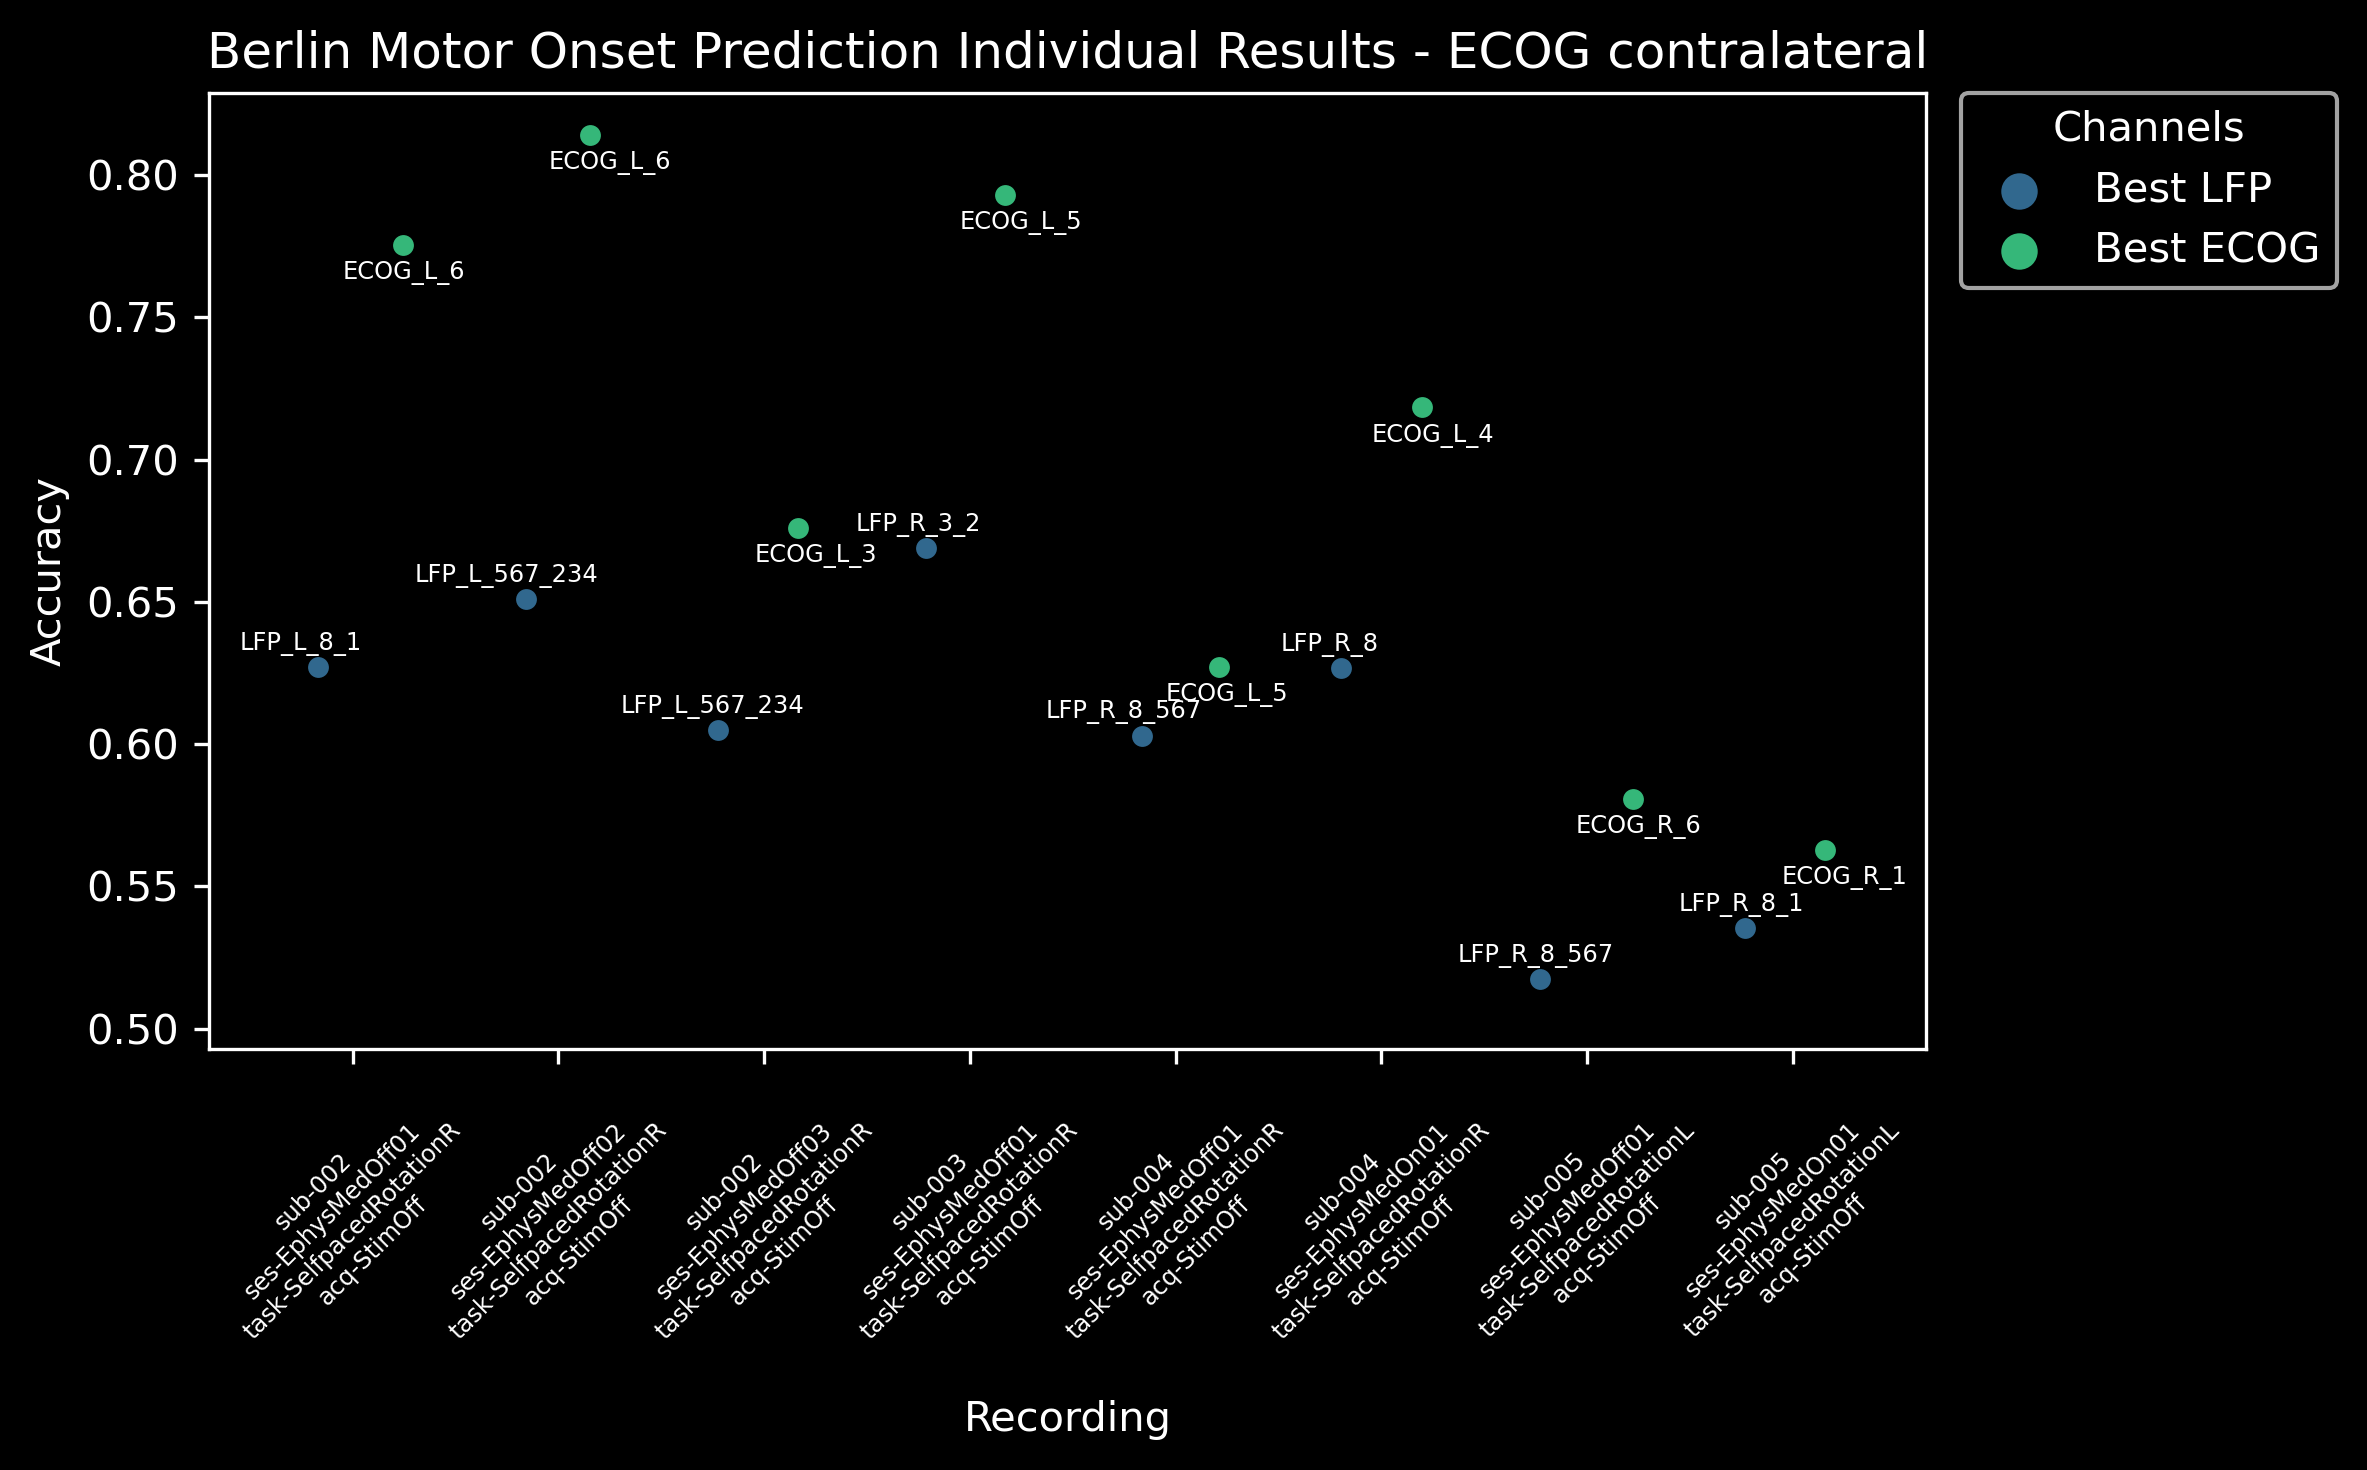

In [13]:
outpath = os.path.join(deriv_root, 'berlin_mot_onset_class_sLDA_no_feat_norm_indiv_scores_contralat_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)

ax = sb.stripplot(x="Recording", y="Accuracy", hue="Channel", 
                  data=df, palette="viridis", dodge=True, s=5)
tick_label = ax.get_xticklabels()
tick_dict = dict()
for x in ax.get_xticks():
    tick_dict[tick_label[x].get_text()] = x
for line, name in enumerate(df.index):
    if "LFP" in df["Best_Channel"][line]:
        x_offset = -0.25
        y_offset = +0.006
        align = 'center'
    elif "ECOG" in df["Best_Channel"][line]:
        x_offset = +0.25
        y_offset = -0.012
        align = 'center'
    ax.text(tick_dict[name]+x_offset, df.Accuracy[line]+y_offset, 
             df.Best_Channel[line], horizontalalignment=align, 
             size='xx-small', color='white')

plt.xticks(rotation=45)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace('_','\n')[:-11] for xtick in xlabels]
ax.set_xticklabels(new_xlabels, fontdict={'fontsize':'xx-small'})
ax.set_xlim(left=ax.get_xlim()[0]-0.2, right=ax.get_xlim()[1]+0.15)
ax.set_ylim(bottom=ax.get_ylim()[0]-0.01)
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)], labels[:len(labels)], 
               bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Channels')
plt.title("Berlin Motor Onset Prediction Individual Results - ECOG contralateral")
plt.tight_layout()
plt.savefig(outpath)

In [14]:
df_list = list()
for file in group_files[2:3]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere', 'Recording'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Recording'] = series.index
            if "LFP" in col:
                best_ch = df.loc[:,"LFP_best_ch"].str.slice(stop=-7)
            elif "ECOG" in col:
                best_ch = df.loc[:,"ECOG_best_ch"].str.slice(stop=-14)
            new_df['Best_Channel'] = best_ch
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

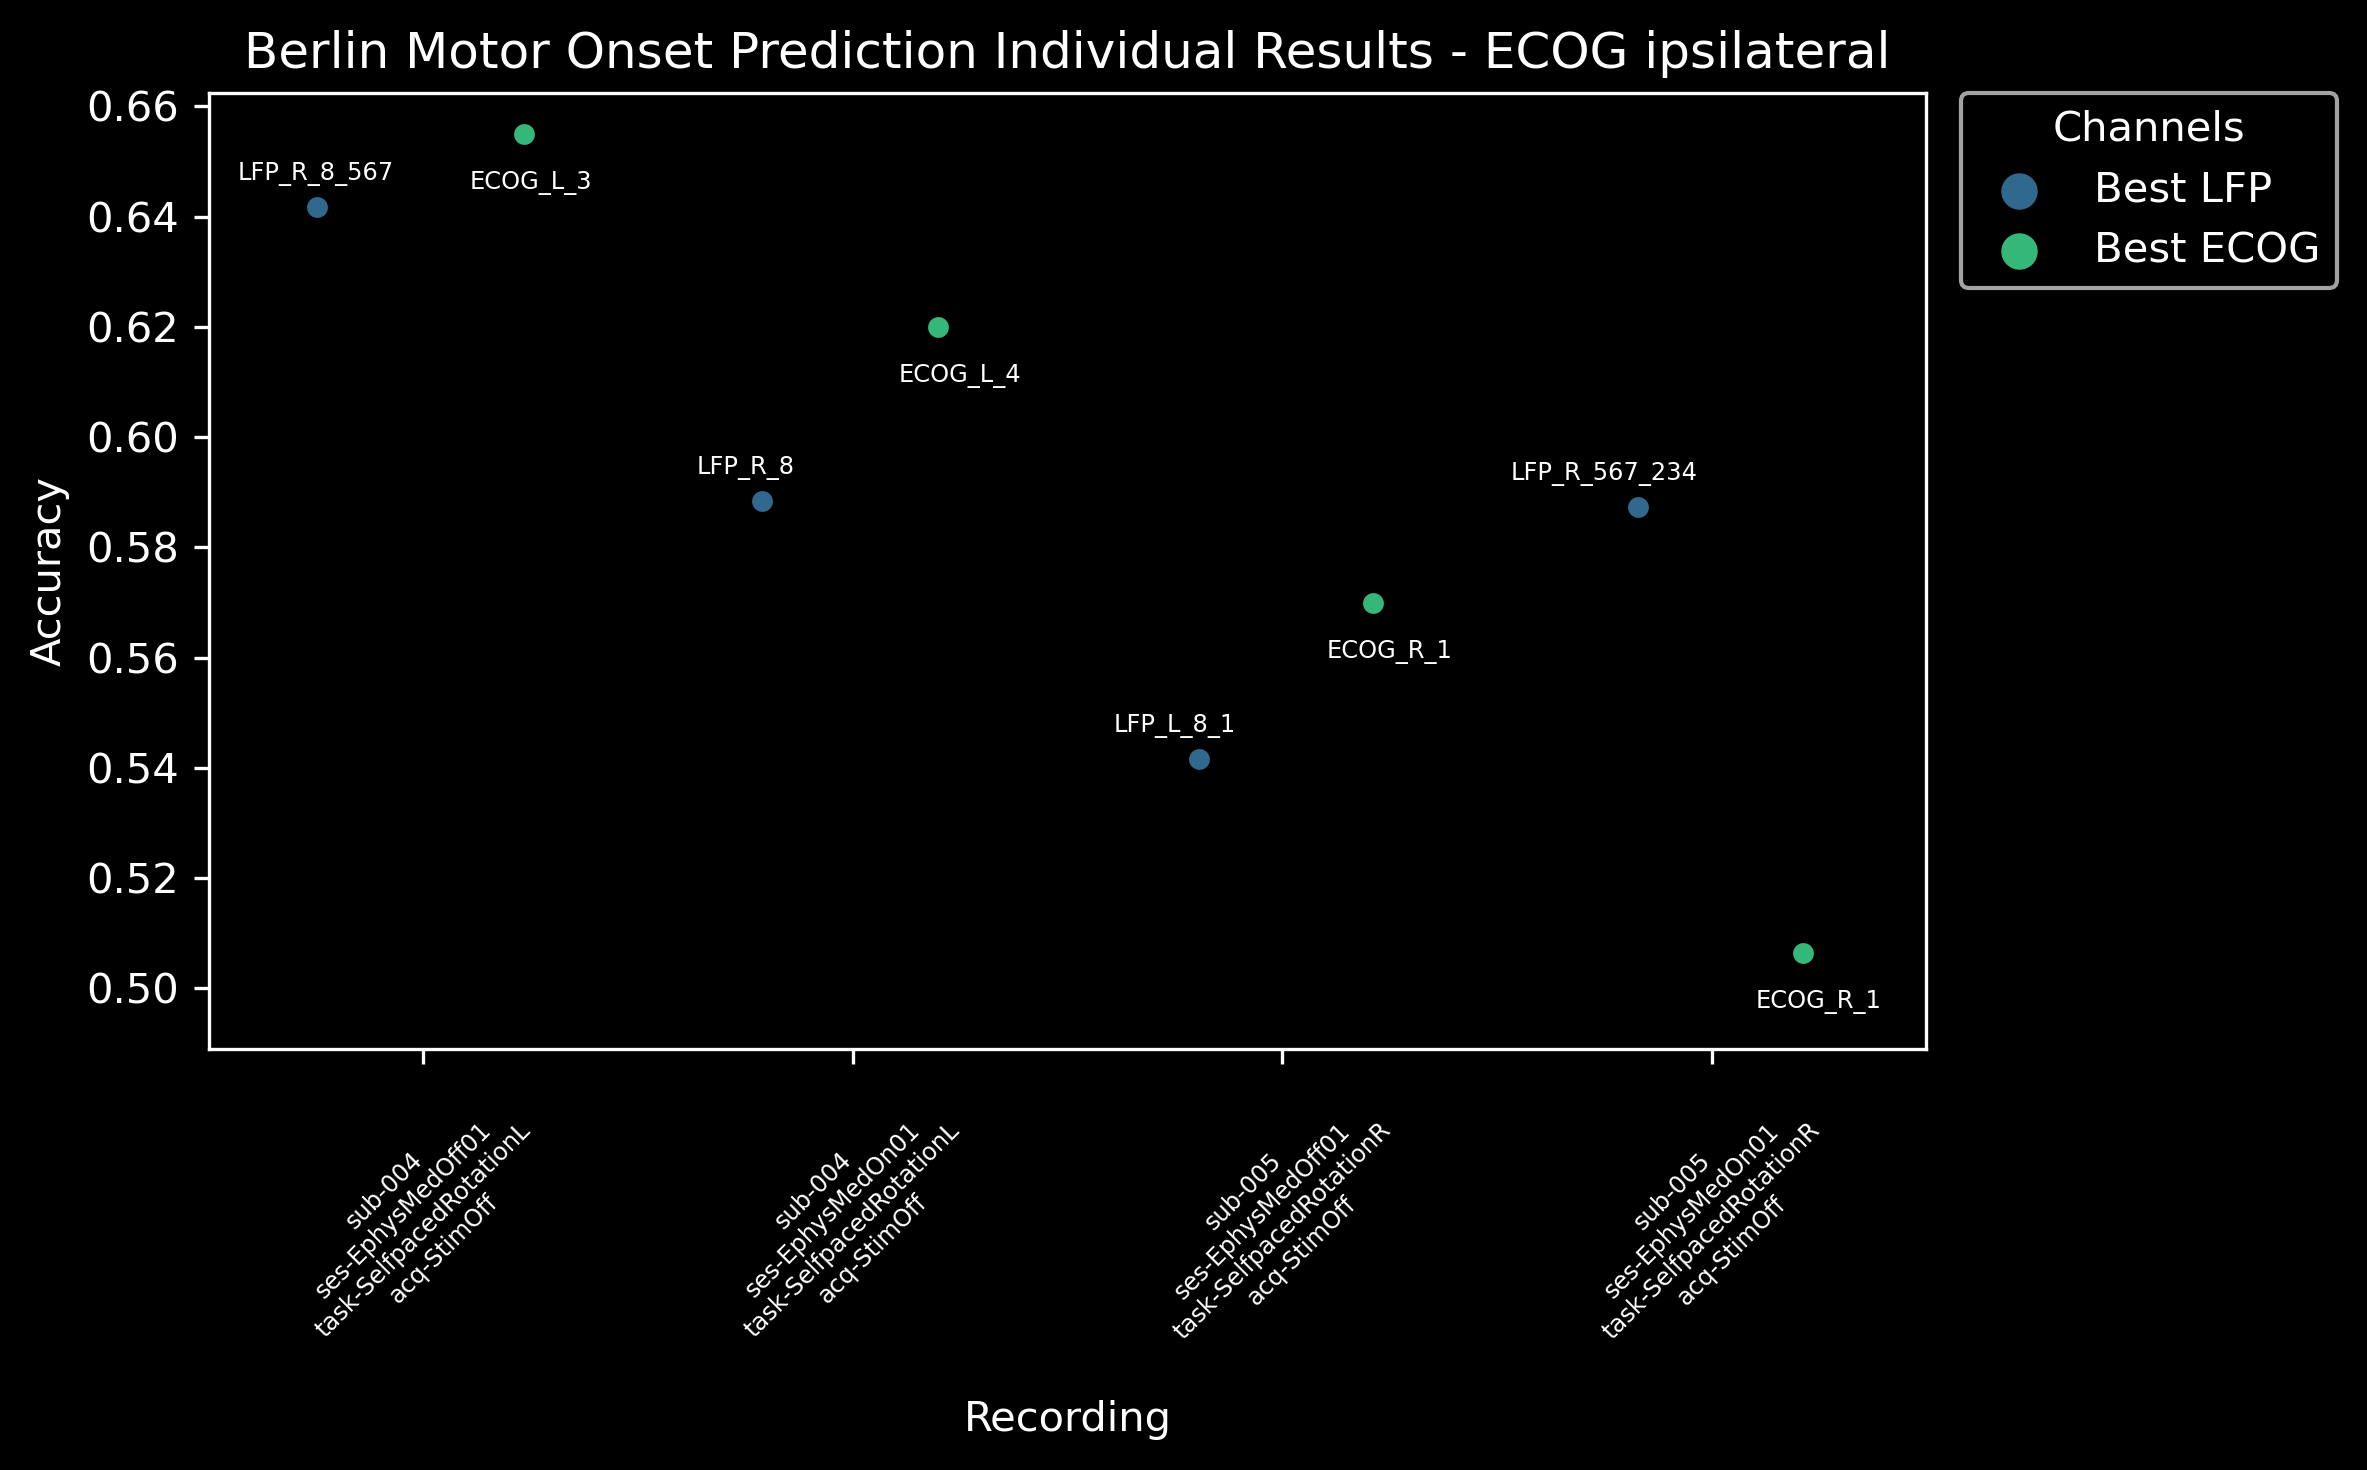

In [16]:
outpath = os.path.join(deriv_root, 'berlin_mot_onset_class_sLDA_no_feat_norm_indiv_scores_ipsilat_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)

ax = sb.stripplot(x="Recording", y="Accuracy", hue="Channel", 
                  data=df, palette="viridis", dodge=True, s=5)
tick_label = ax.get_xticklabels()
tick_dict = dict()
for x in ax.get_xticks():
    tick_dict[tick_label[x].get_text()] = x
for line, name in enumerate(df.index):
    if "LFP" in df["Best_Channel"][line]:
        x_offset = -0.25
        y_offset = +0.005
        align = 'center'
    elif "ECOG" in df["Best_Channel"][line]:
        x_offset = +0.25
        y_offset = -0.01
        align = 'center'
    ax.text(tick_dict[name]+x_offset, df.Accuracy[line]+y_offset, 
             df.Best_Channel[line], horizontalalignment=align, 
             size='xx-small', color='white')

plt.xticks(rotation=45)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace('_','\n')[:-11] for xtick in xlabels]
ax.set_xticklabels(new_xlabels, fontdict={'fontsize':'xx-small'})
#ax.set_xlim(left=ax.get_xlim()[0]-0.2, right=ax.get_xlim()[1]+0.15)
ax.set_ylim(bottom=ax.get_ylim()[0]-0.01)
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)], labels[:len(labels)], 
               bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Channels')
plt.title("Berlin Motor Onset Prediction Individual Results - ECOG ipsilateral")
plt.tight_layout()
plt.savefig(outpath)

In [17]:
df_list = list()
for file in group_files[0::2]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

In [18]:
final_df.columns

Index(['Accuracy', 'Channel', 'Hemisphere'], dtype='object')

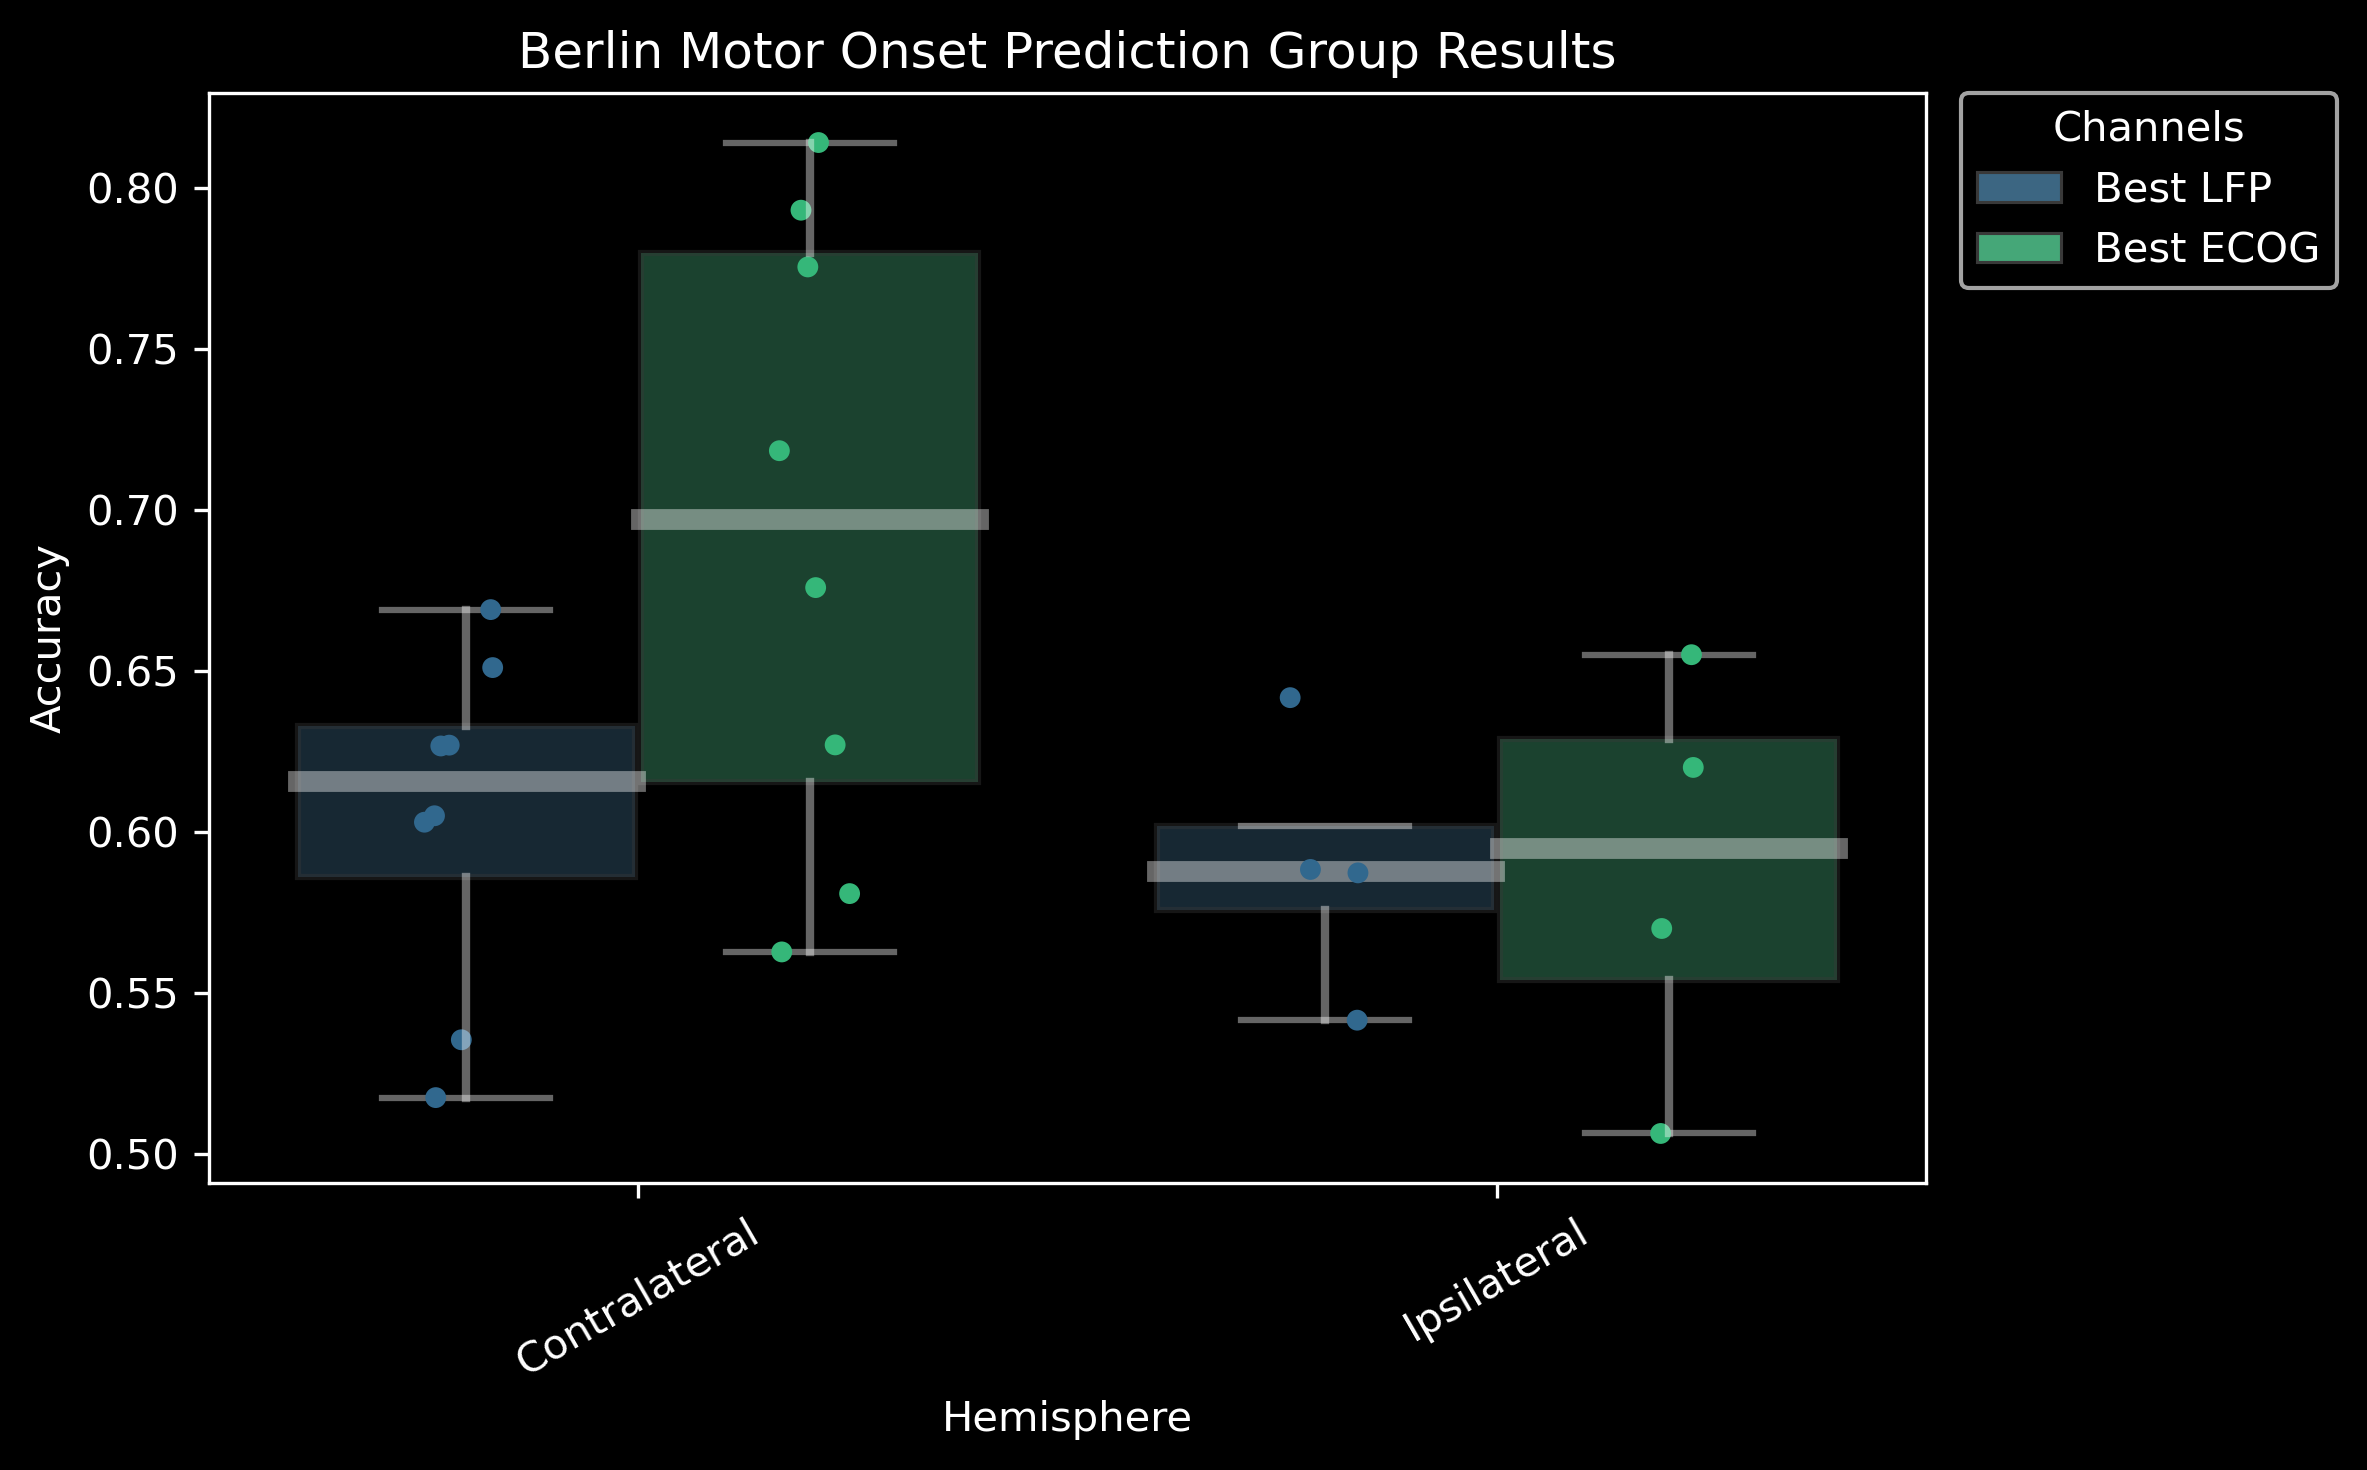

In [19]:
outpath = os.path.join(deriv_root, 'berlin_mot_onset_class_sLDA_no_feat_norm_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)
scores = ['Contralateral', 'Ipsilateral']
sb.boxplot(x="Hemisphere", y="Accuracy", hue="Channel", order=scores, 
           data=df, palette="viridis",
           showmeans=False, boxprops=dict(alpha=alpha_box), showcaps=True, showbox=True, 
           showfliers=False, notch=False,
           whiskerprops={'linewidth':2, "zorder":10, "alpha":alpha_box, "color":'white'},
           capprops={"alpha":alpha_box,"color":'white'},
           medianprops=dict(linestyle='-', linewidth=5, color="white", alpha=alpha_box))

ax = sb.stripplot(x="Hemisphere", y="Accuracy", hue="Channel", order=scores, 
             data=df,palette="viridis", dodge=True, s=5)

plt.xticks(rotation=30)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace(' ','\n') for xtick in xlabels]
ax.set_xticklabels(new_xlabels) 
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)//2], labels[:len(labels)//2], bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Channels')
plt.title("Berlin Motor Onset Prediction Group Results")
plt.tight_layout()
plt.savefig(outpath)

# Movement

In [20]:
df_list = list()
for file in group_files[1:2]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere', 'Recording'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Recording'] = series.index
            if "LFP" in col:
                best_ch = df.loc[:,"LFP_best_ch"].str.slice(stop=-7)
            elif "ECOG" in col:
                best_ch = df.loc[:,"ECOG_best_ch"].str.slice(stop=-14)
            new_df['Best_Channel'] = best_ch
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

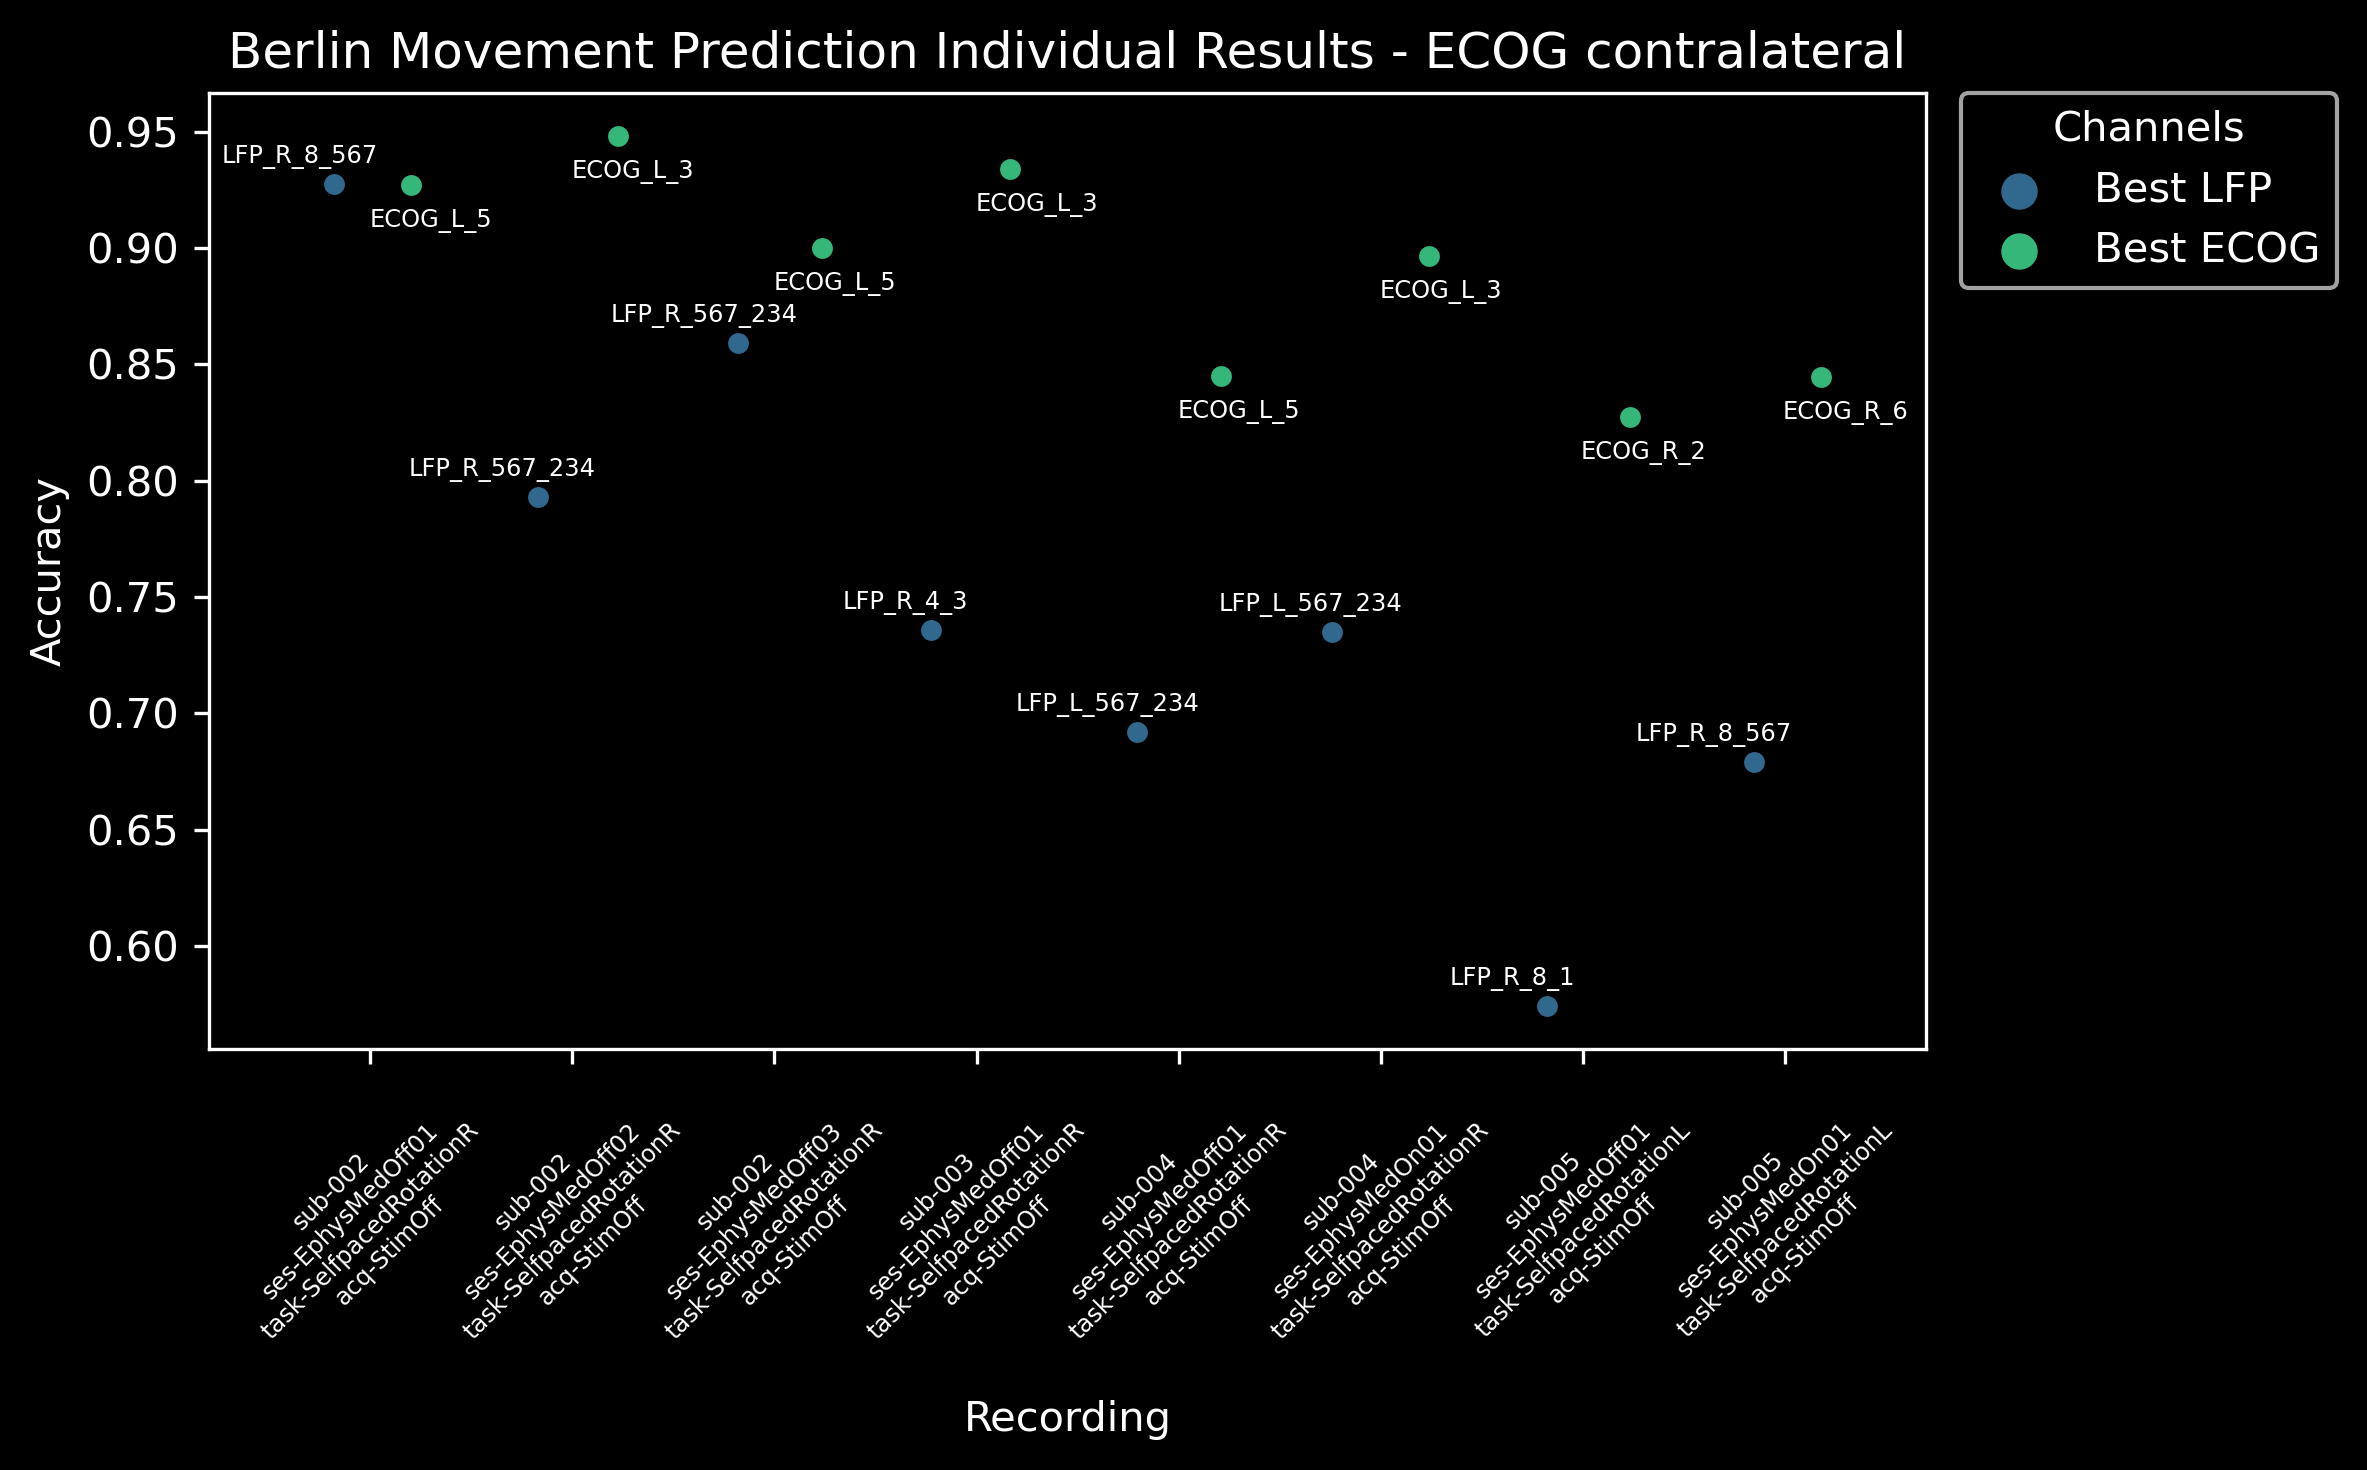

In [21]:
outpath = os.path.join(deriv_root, 'berlin_movement_class_sLDA_no_feat_norm_indiv_scores_contralat_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)

ax = sb.stripplot(x="Recording", y="Accuracy", hue="Channel", 
                  data=df, palette="viridis", dodge=True, s=5)
tick_label = ax.get_xticklabels()
tick_dict = dict()
for x in ax.get_xticks():
    tick_dict[tick_label[x].get_text()] = x
for line, name in enumerate(df.index):
    if "LFP" in df["Best_Channel"][line]:
        x_offset = -0.35
        y_offset = +0.009
        align = 'center'
    elif "ECOG" in df["Best_Channel"][line]:
        x_offset = +0.3
        y_offset = -0.018
        align = 'center'
    ax.text(tick_dict[name]+x_offset, df.Accuracy[line]+y_offset, 
             df.Best_Channel[line], horizontalalignment=align, 
             size='xx-small', color='white')

plt.xticks(rotation=45)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace('_','\n')[:-11] for xtick in xlabels]
ax.set_xticklabels(new_xlabels, fontdict={'fontsize':'xx-small'})
ax.set_xlim(left=ax.get_xlim()[0]-0.3, right=ax.get_xlim()[1]+0.2)
#ax.set_ylim(bottom=ax.get_ylim()[0]-0.01)
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)], labels[:len(labels)], 
               bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Channels')
plt.title("Berlin Movement Prediction Individual Results - ECOG contralateral")
plt.tight_layout()
plt.savefig(outpath)

In [22]:
df_list = list()
for file in group_files[3:]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere', 'Recording'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Recording'] = series.index
            if "LFP" in col:
                best_ch = df.loc[:,"LFP_best_ch"].str.slice(stop=-7)
            elif "ECOG" in col:
                best_ch = df.loc[:,"ECOG_best_ch"].str.slice(stop=-14)
            new_df['Best_Channel'] = best_ch
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

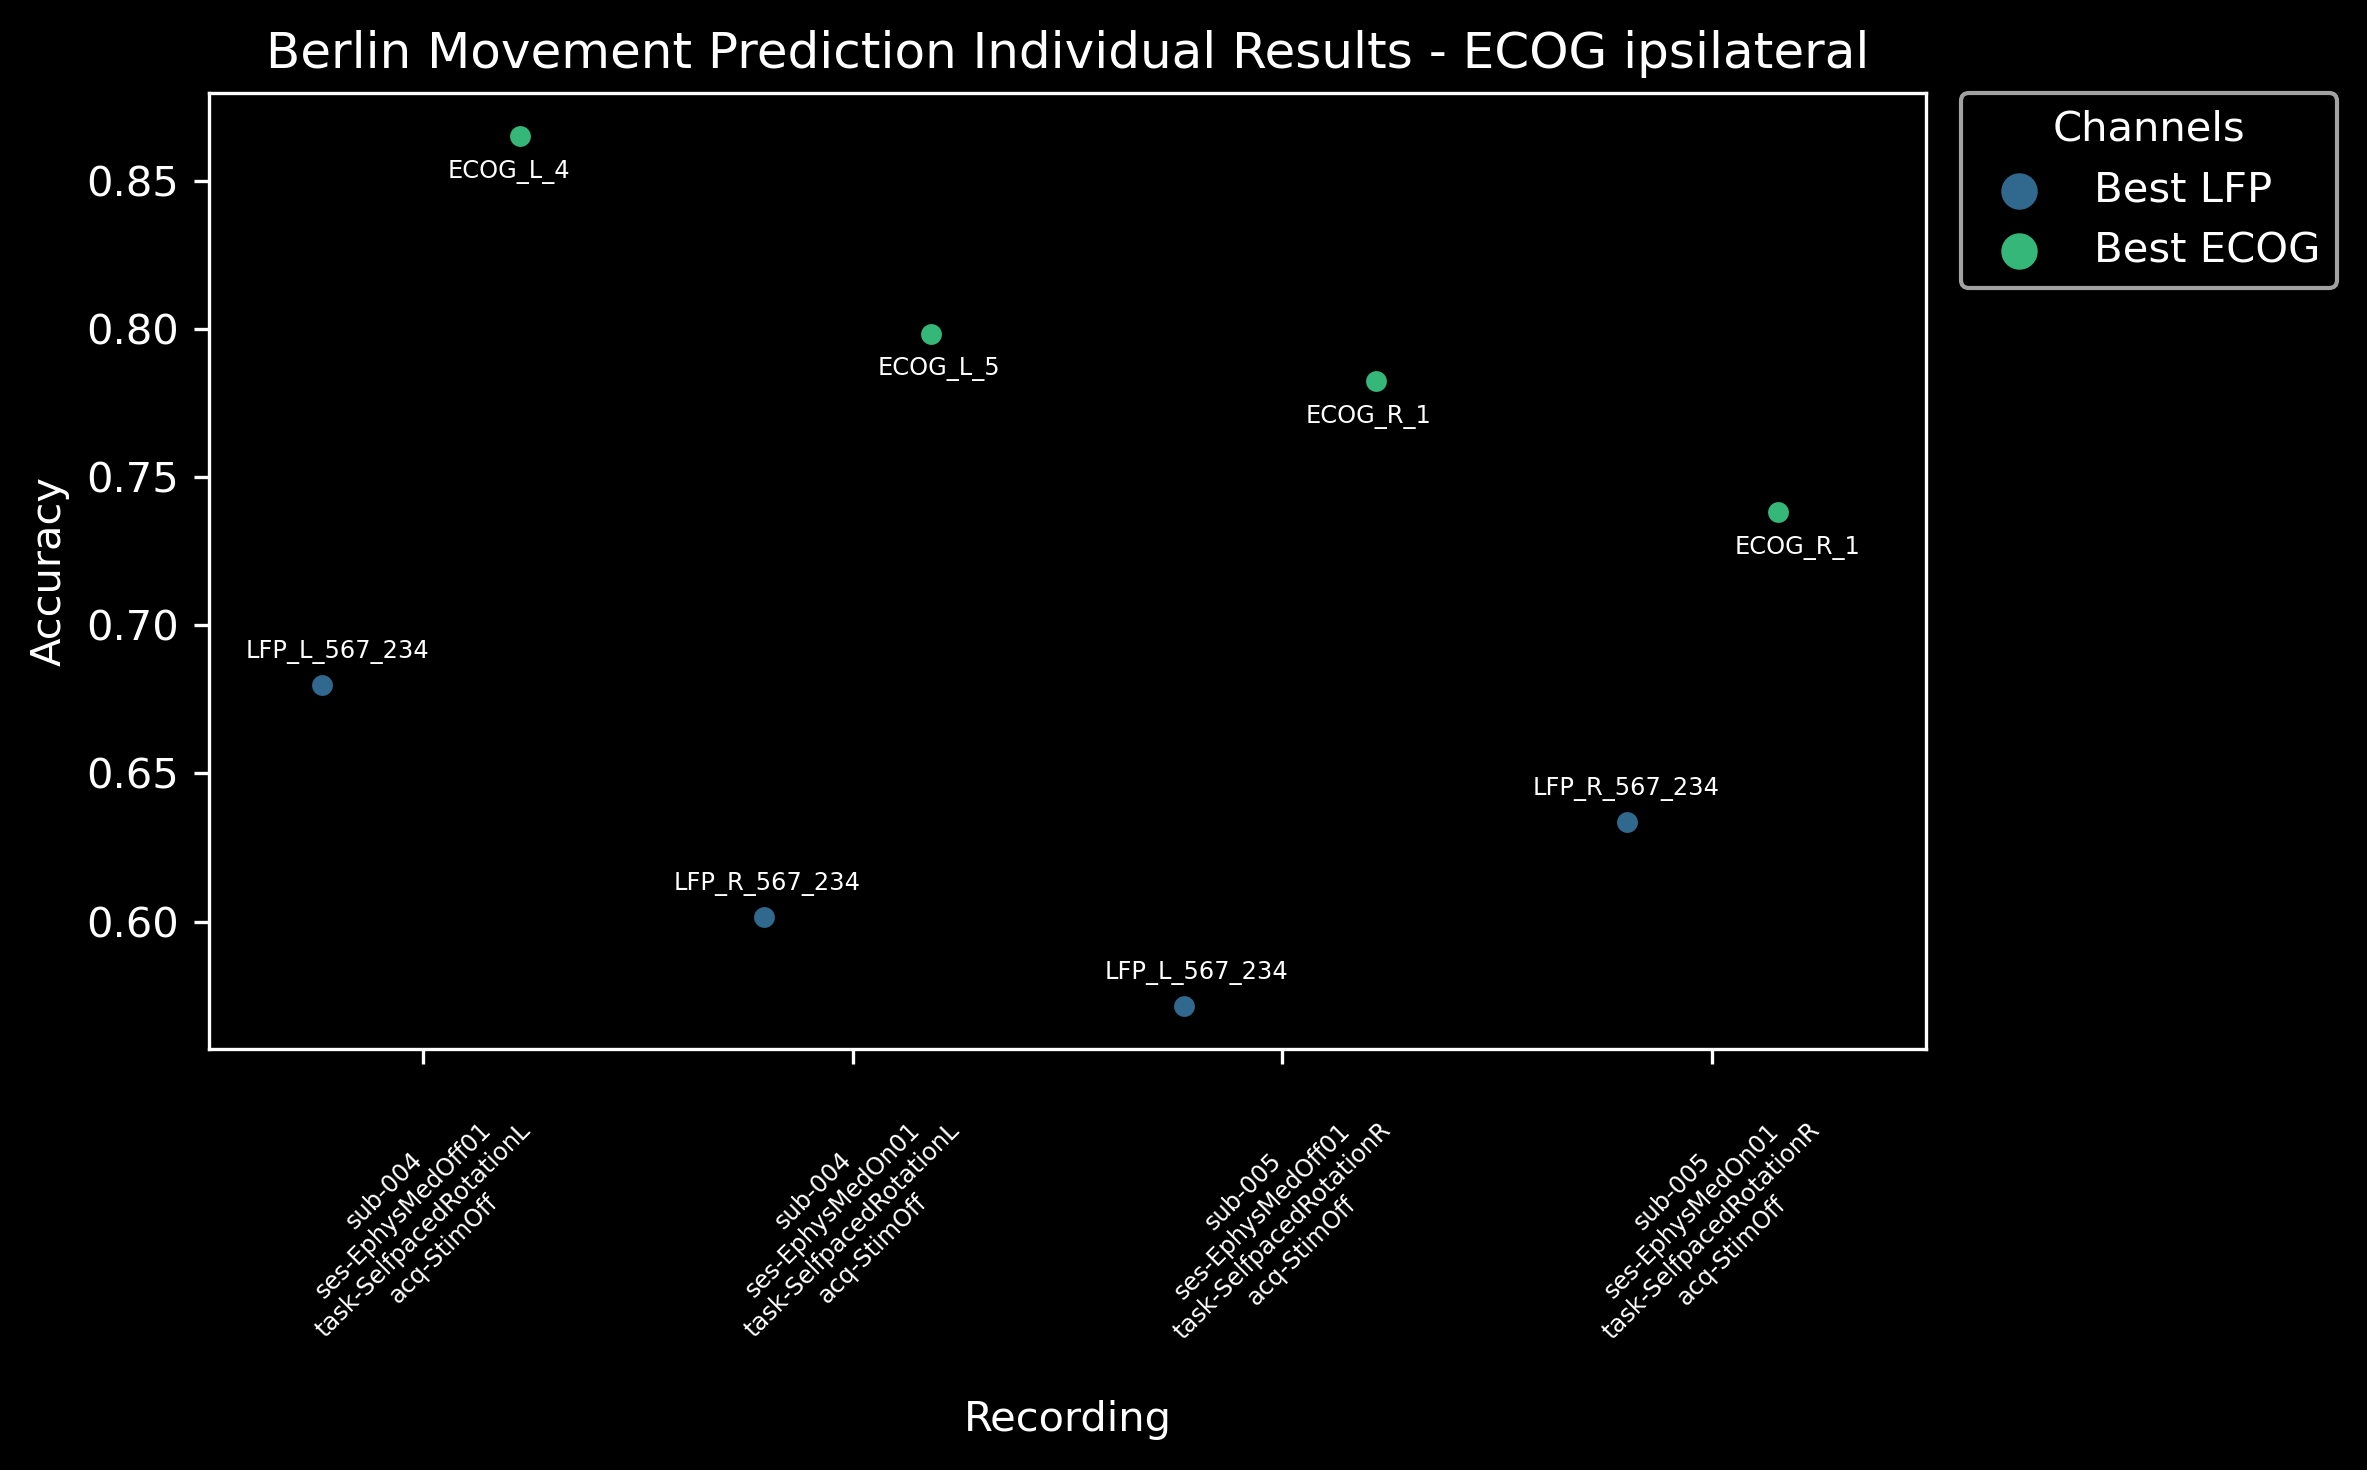

In [23]:
outpath = os.path.join(deriv_root, 'berlin_movement_class_sLDA_no_feat_norm_indiv_scores_ipsilat_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)

ax = sb.stripplot(x="Recording", y="Accuracy", hue="Channel", 
                  data=df, palette="viridis", dodge=True, s=5)
tick_label = ax.get_xticklabels()
tick_dict = dict()
for x in ax.get_xticks():
    tick_dict[tick_label[x].get_text()] = x
for line, name in enumerate(df.index):
    if "LFP" in df["Best_Channel"][line]:
        x_offset = -0.2
        y_offset = +0.009
        align = 'center'
    elif "ECOG" in df["Best_Channel"][line]:
        x_offset = +0.2
        y_offset = -0.014
        align = 'center'
    ax.text(tick_dict[name]+x_offset, df.Accuracy[line]+y_offset, 
             df.Best_Channel[line], horizontalalignment=align, 
             size='xx-small', color='white')

plt.xticks(rotation=45)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace('_','\n')[:-11] for xtick in xlabels]
ax.set_xticklabels(new_xlabels, fontdict={'fontsize':'xx-small'})
ax.set_xlim(left=ax.get_xlim()[0]-0.0, right=ax.get_xlim()[1]+0.0)
#ax.set_ylim(bottom=ax.get_ylim()[0]-0.01)
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)], labels[:len(labels)], 
               bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Channels')
plt.title("Berlin Movement Prediction Individual Results - ECOG ipsilateral")
plt.tight_layout()
plt.savefig(outpath)

In [24]:
df_list = list()
for file in group_files[:2]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere', 'Recording'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Recording'] = series.index
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

In [25]:
df_list = list()
for file in group_files[1::2]:
    df = pd.read_csv(file, sep='\t', index_col=[0], header=[0])
    for col in df.columns:
        if "accuracy" in col:
            new_df = pd.DataFrame(columns = ['Accuracy', 'Channel', 'Hemisphere'], index=df.index)
            series = pd.Series(df[col], index=df.index)
            new_df['Accuracy'] = series
            new_df['Channel'] = "Best LFP" if "LFP" in col else "Best ECOG"
            new_df['Hemisphere'] = "Contralateral" if "Contralateral" in file else "Ipsilateral"
            df_list.append(new_df)
final_df = pd.concat(df_list)

In [26]:
final_df.columns

Index(['Accuracy', 'Channel', 'Hemisphere'], dtype='object')

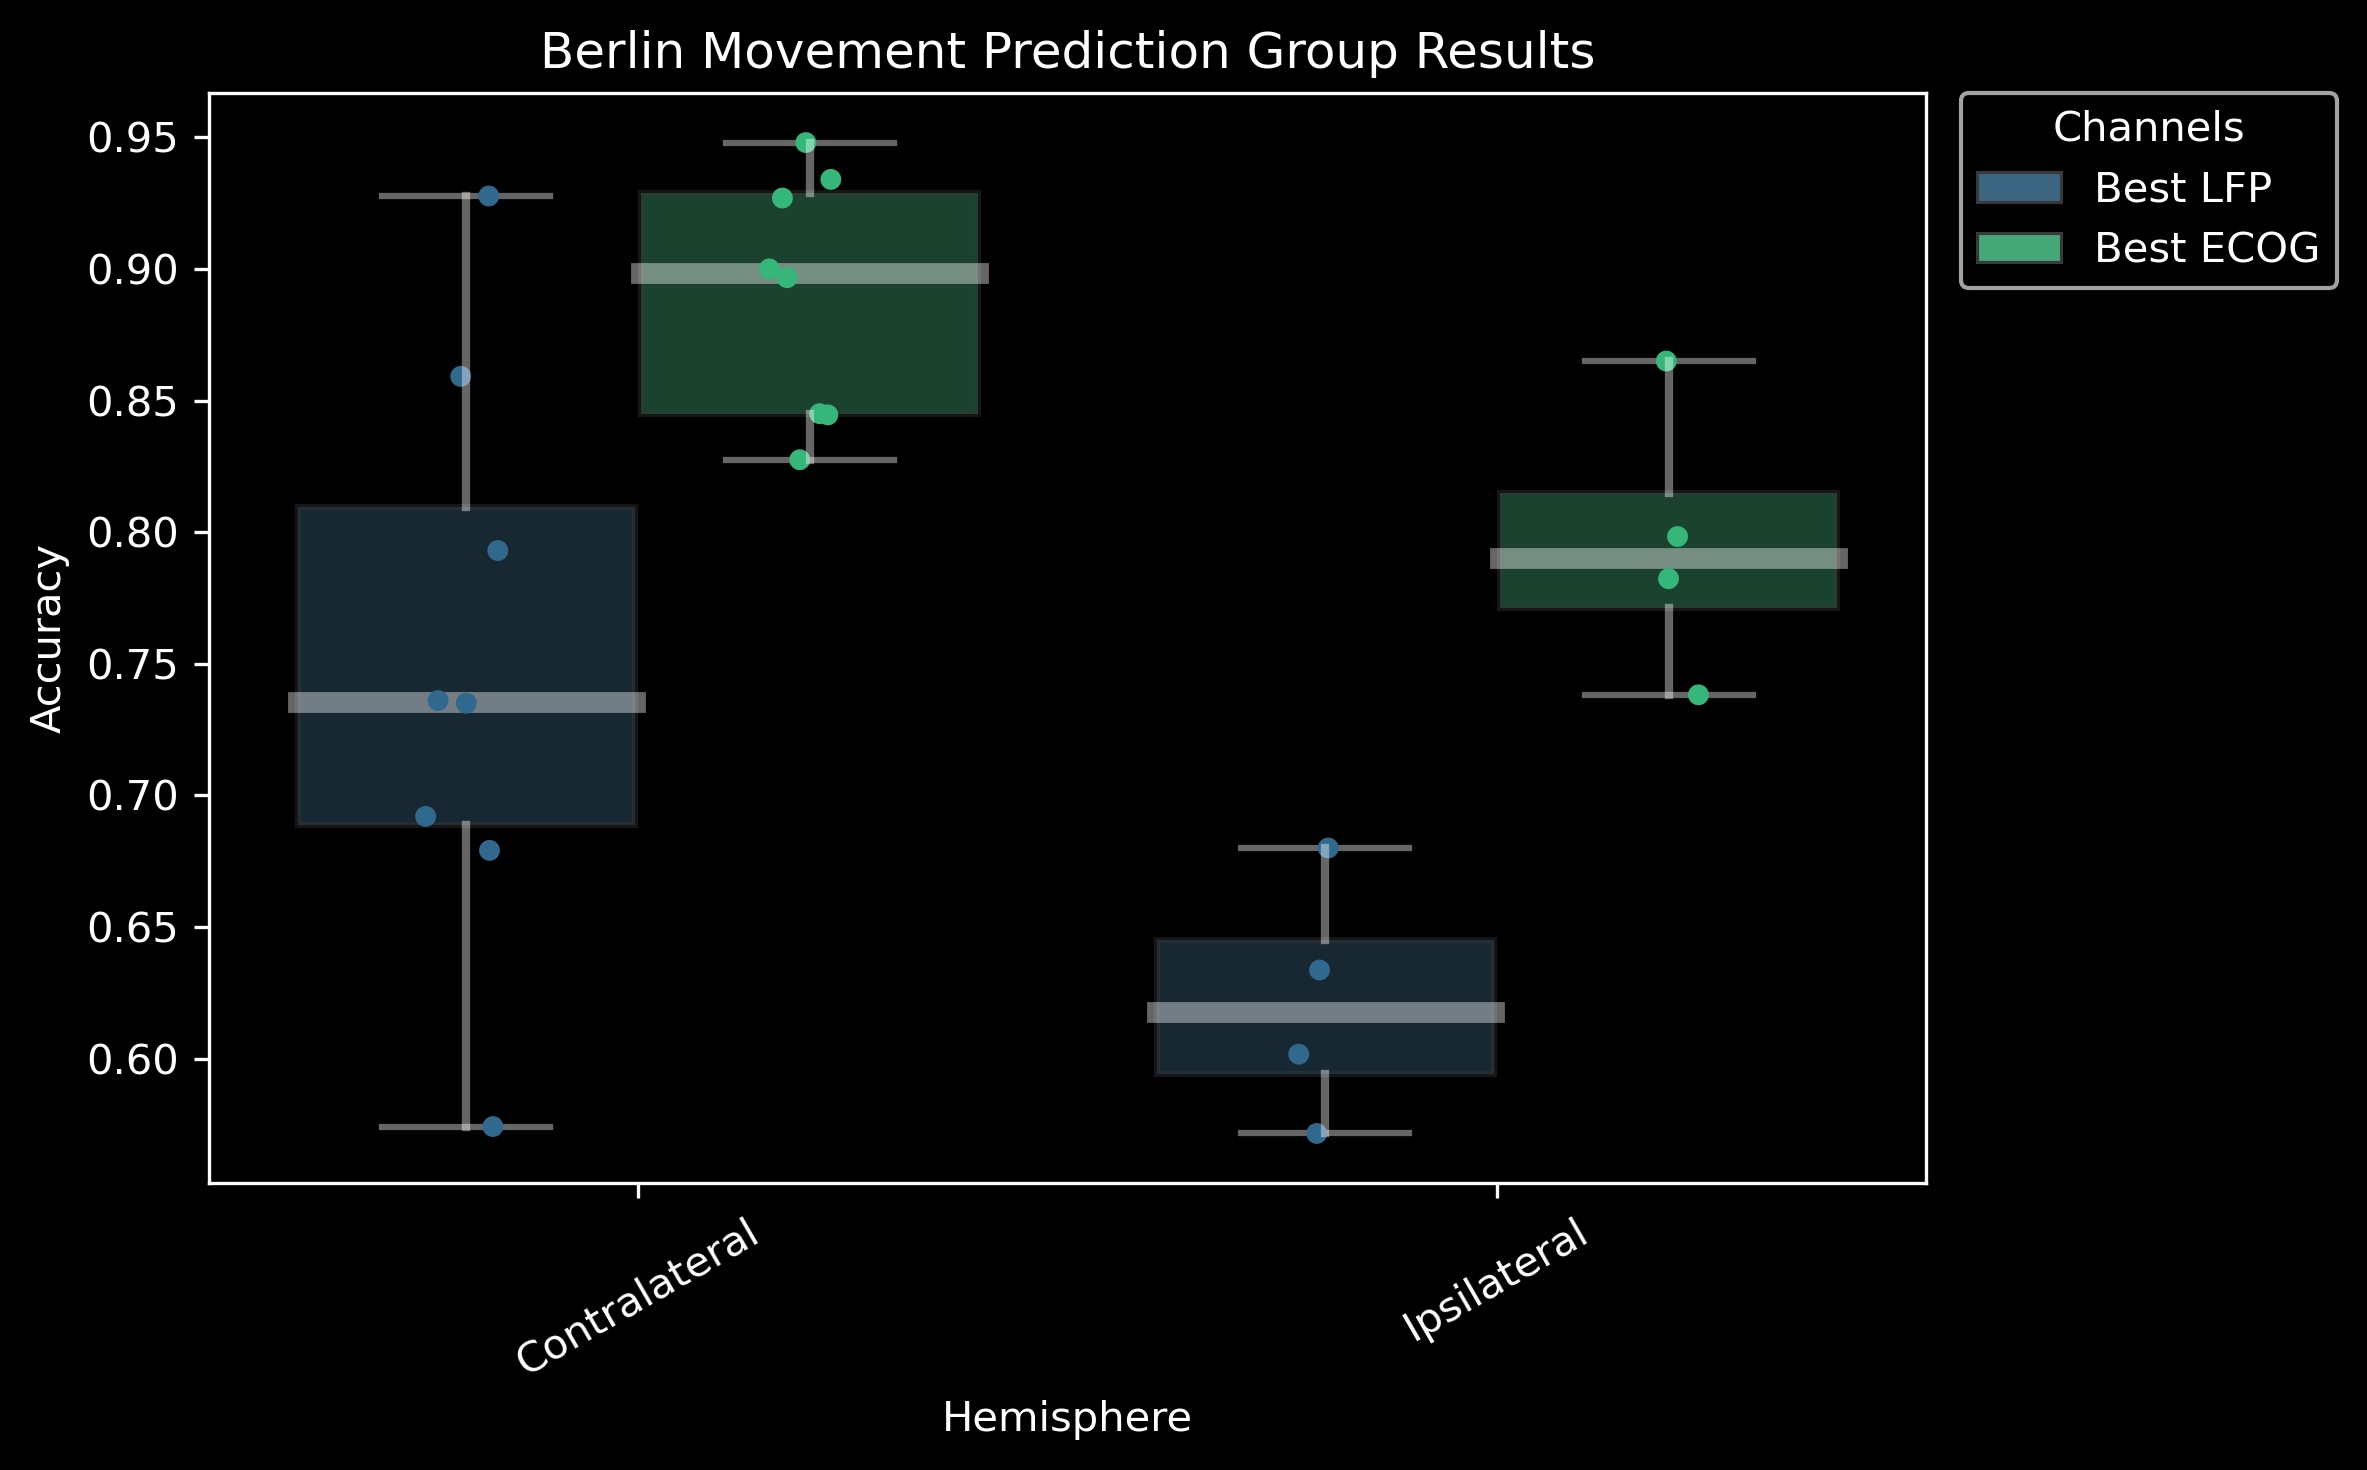

In [27]:
outpath = os.path.join(deriv_root, 'berlin_movement_class_sLDA_no_feat_norm_dark.png')
df = final_df
plt.style.use('dark_background')
alpha_box = 0.4
plt.figure(figsize=(8,5), dpi=300)
scores = ['Contralateral', 'Ipsilateral']
sb.boxplot(x="Hemisphere", y="Accuracy", hue="Channel", order=scores, 
           data=df, palette="viridis",
           showmeans=False, boxprops=dict(alpha=alpha_box), showcaps=True, showbox=True, 
           showfliers=False, notch=False,
           whiskerprops={'linewidth':2, "zorder":10, "alpha":alpha_box, "color":'white'},
           capprops={"alpha":alpha_box,"color":'white'},
           medianprops=dict(linestyle='-', linewidth=5, color="white", alpha=alpha_box))

ax = sb.stripplot(x="Hemisphere", y="Accuracy", hue="Channel", order=scores, 
             data=df,palette="viridis", dodge=True, s=5)

plt.xticks(rotation=30)
xlabels = [item.get_text() for item in ax.get_xticklabels()]
new_xlabels = [xtick.replace(' ','\n') for xtick in xlabels]
ax.set_xticklabels(new_xlabels) 
handles, labels = ax.get_legend_handles_labels()
l = plt.legend(handles[:len(handles)//2], labels[:len(labels)//2], bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title='Channels')
plt.title("Berlin Movement Prediction Group Results")
plt.tight_layout()
plt.savefig(outpath)

# CONTINUE

In [36]:

from scipy import stats
a = np.array([[ 0.7972,  0.0767,  0.4383,  0.7866,  0.8091],
             [0.1954,  0.6307,  0.6599,  0.1065,  0.0508]]).T
print(a)
print(a.shape)
print(stats.zscore(a, axis = 0))

[[0.7972 0.1954]
 [0.0767 0.6307]
 [0.4383 0.6599]
 [0.7866 0.1065]
 [0.8091 0.0508]]
(5, 2)
[[ 0.7477764  -0.50711554]
 [-1.75093844  1.14940099]
 [-0.49689918  1.26052041]
 [ 0.71101529 -0.84542089]
 [ 0.78904594 -1.05738498]]


sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


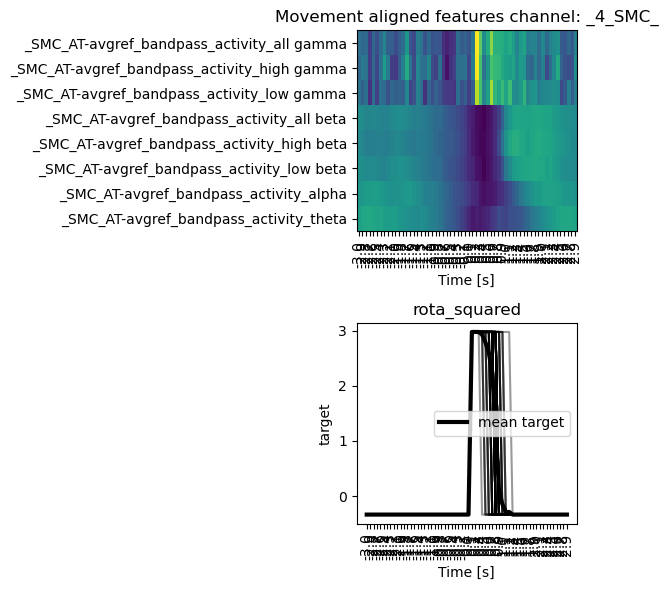

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


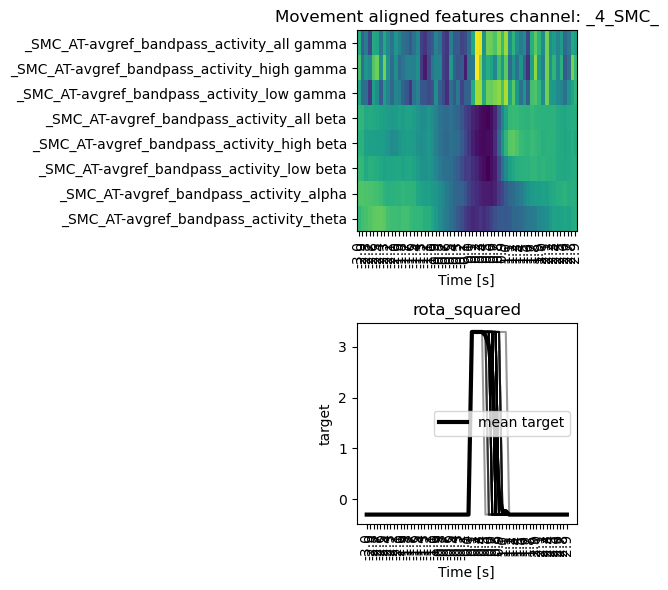

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


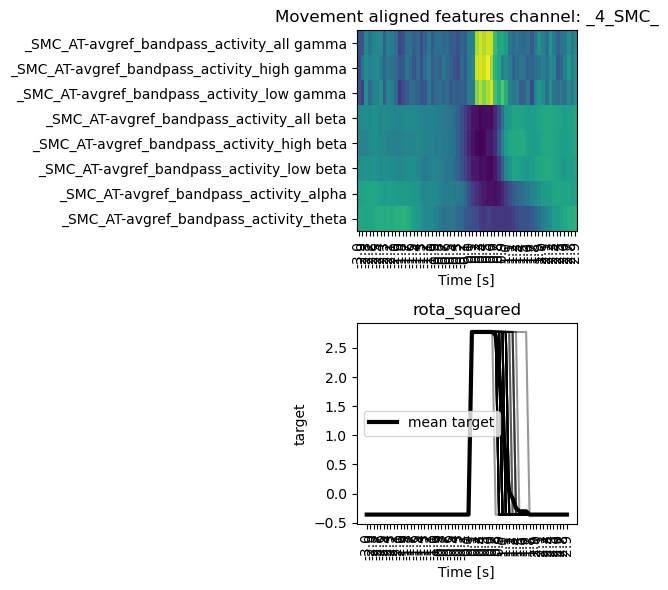

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


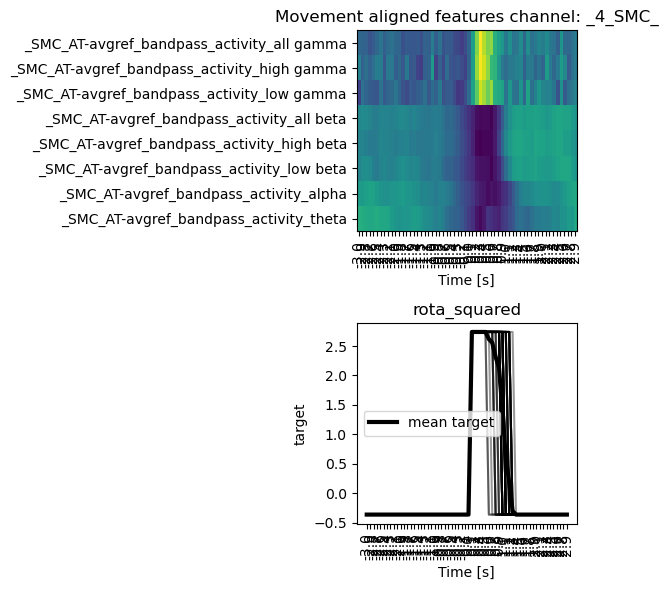

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


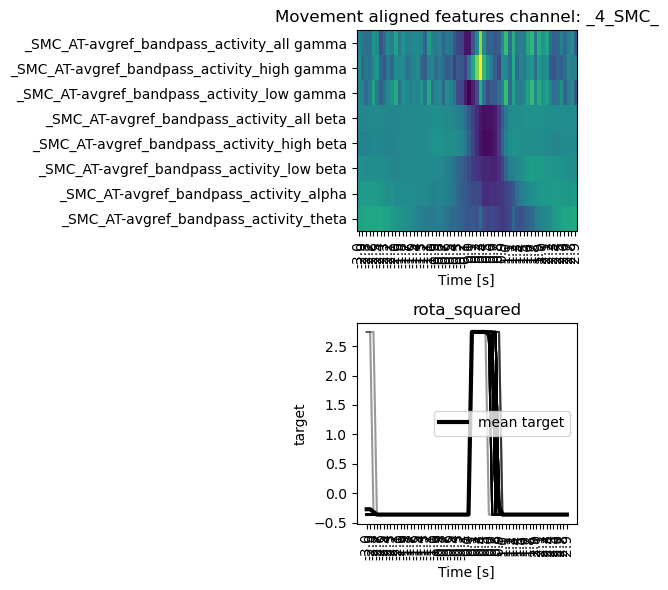

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


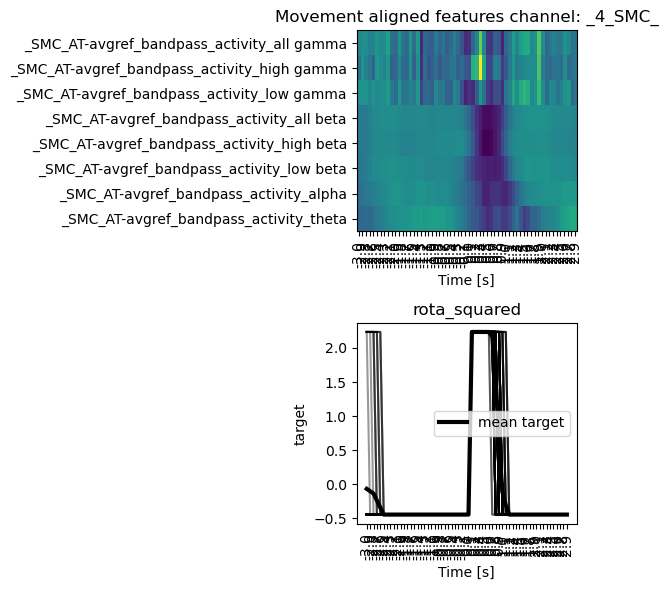

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


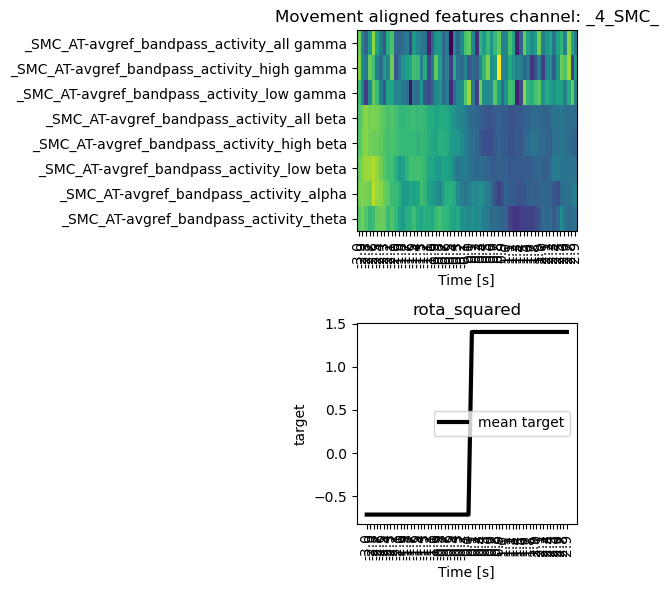

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


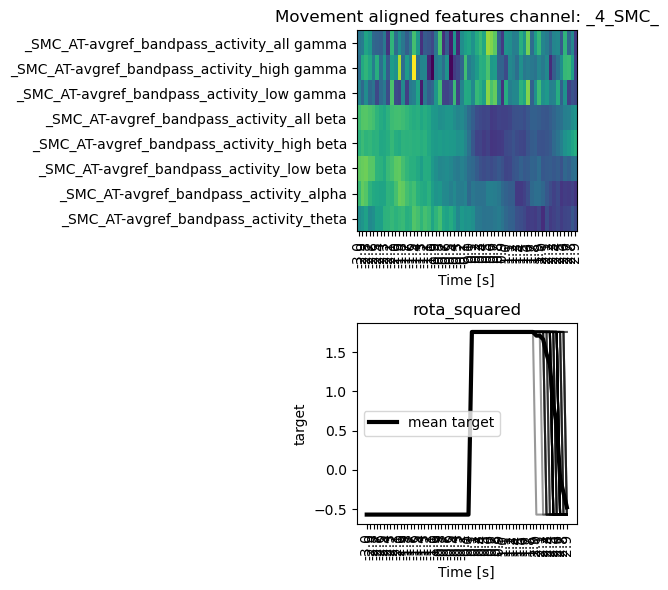

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


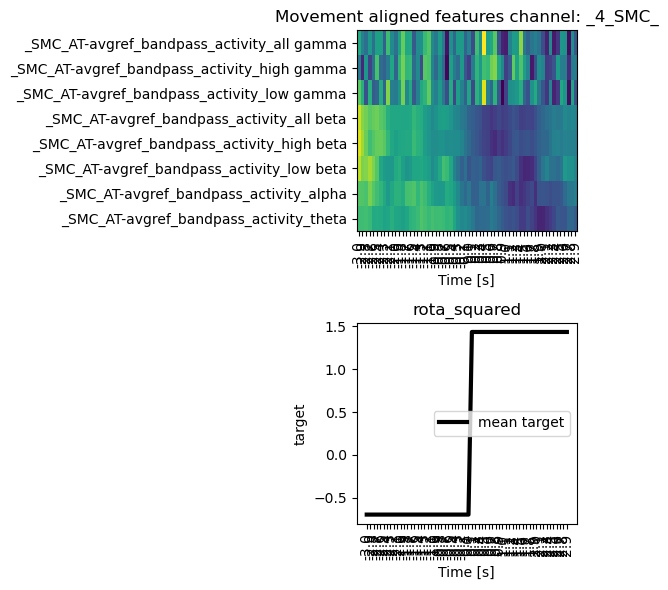

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


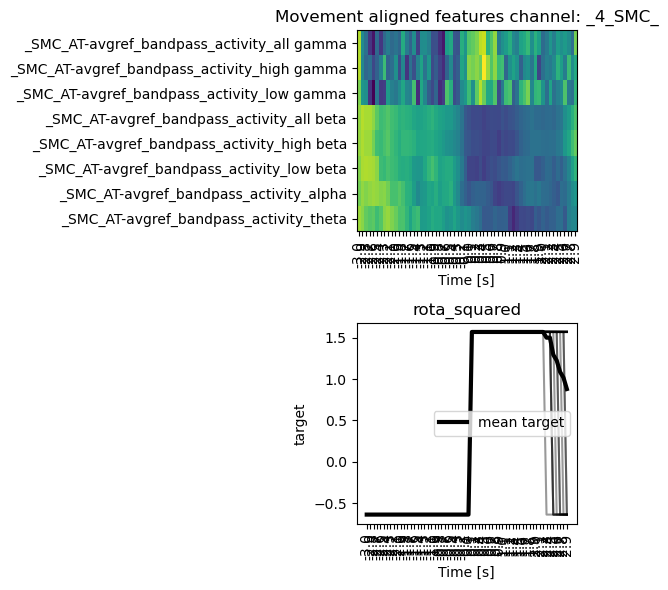

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


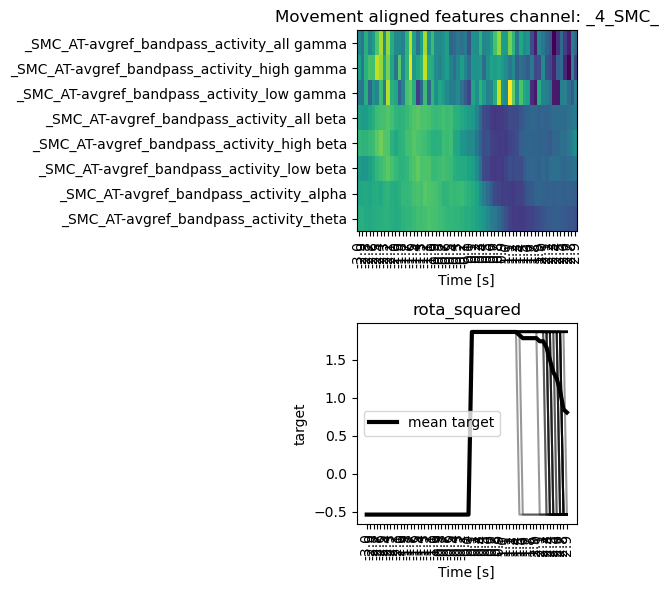

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


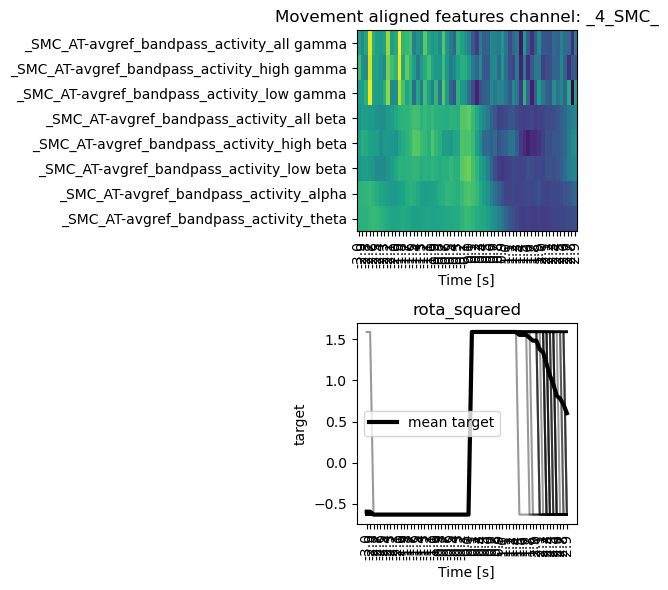

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-005_ses-EphysMedOff02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


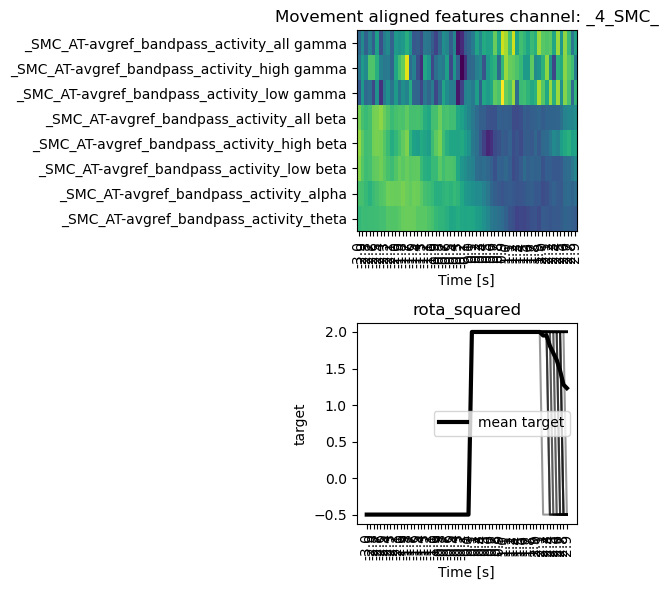

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-005_ses-EphysMedOff02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-005_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


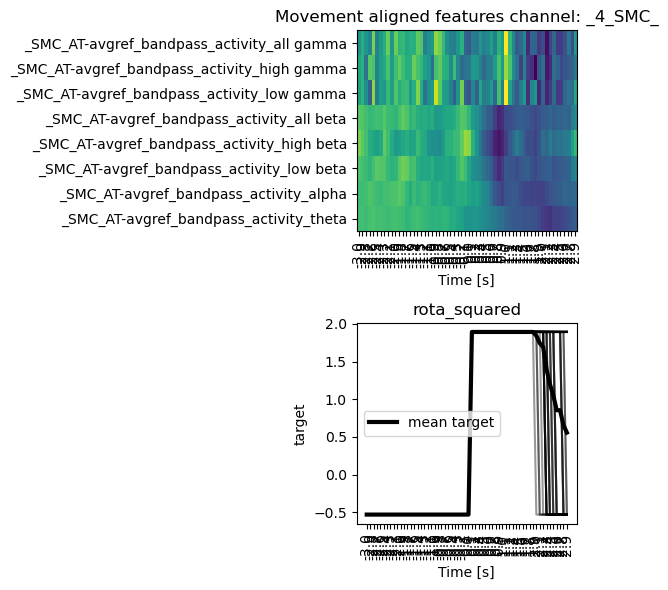

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-005_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


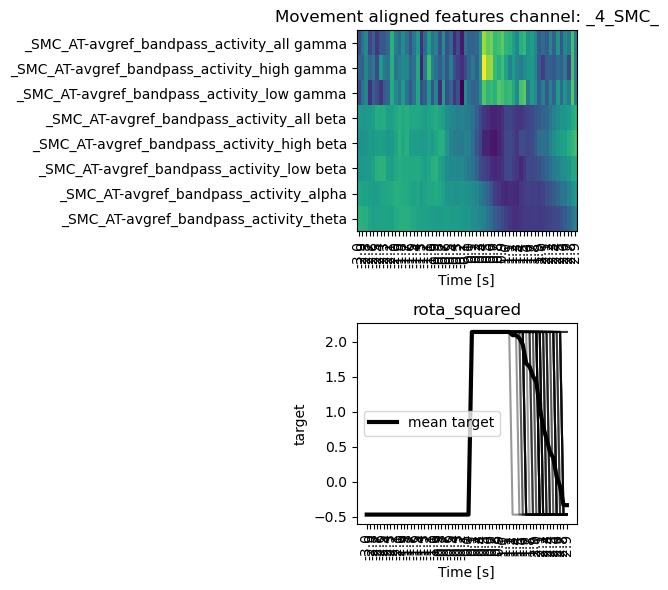

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-005_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


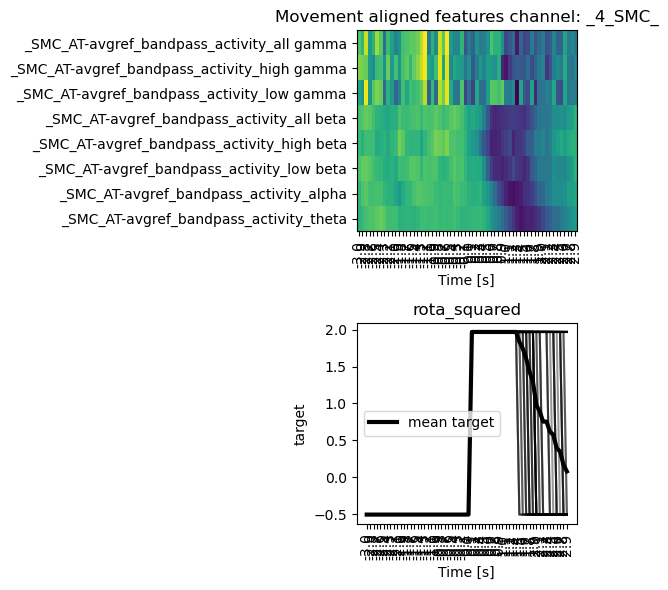

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-005_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-005_ses-EphysMedOn02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


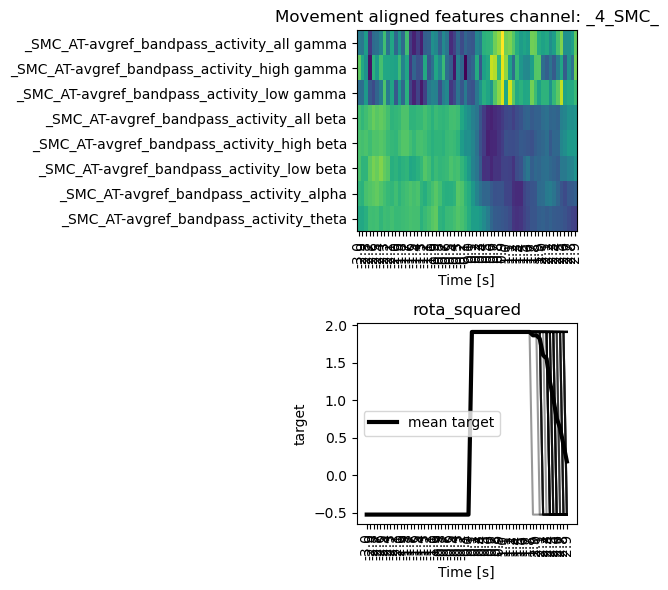

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-005_ses-EphysMedOn02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png
sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg
no _ML file computed
Plotting feature target averaged.
(60, 8)


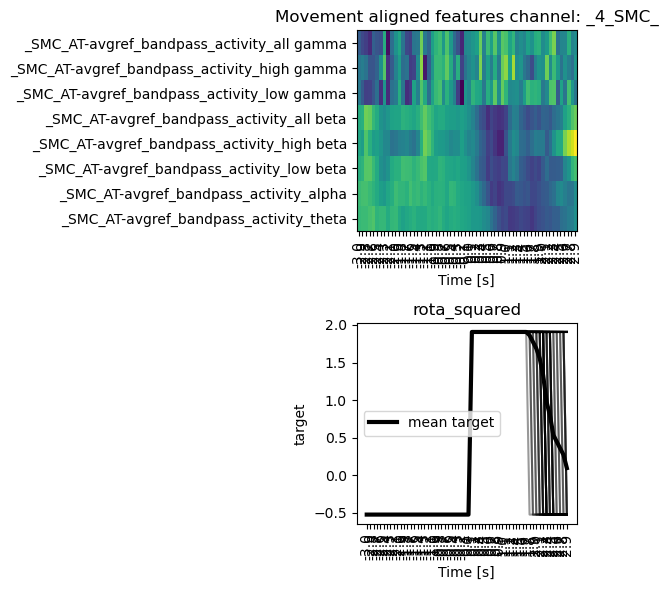

Feature epoch average figure saved to: C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm\sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg\MOV_algined_features_ch__4_SMC__bandpass.png


In [29]:
import importlib
importlib.reload(NM_reader)

%matplotlib inline
plt.style.use('default')
nm_reader = NM_reader.NM_Reader(deriv_root)
feature_list = nm_reader.get_feature_list()
for feature_file in feature_list[:]:
    print(feature_file)
    run_example_read_features(feature_file, ch_name="_4_SMC_", label='rota_squared')

In [55]:
deriv_root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_clip'
nm_reader = NM_reader.NM_Reader(deriv_root)
feature_list = nm_reader.get_feature_list()
print(*feature_list, sep='\n')

sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOff02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg
sub-005_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg
sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOn02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics


for i in range(len(feature_list)):
    feature_file = feature_list[i]
    
    print(i, feature_file)
    features_ = nm_reader.read_features(feature_file)
    bp_act_cols = [
        i for i in list(features_.columns) if all(
            x in i for x in ('4_SMC_', 'bandpass', 'activity'))]
    bp_act_feats = features_[bp_act_cols]
    X = np.array(bp_act_feats)
    y = np.array(features_["rota_squared"])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=0.2, shuffle=False)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, train_size=0.8, shuffle=False)
    classes_weights = class_weight.compute_sample_weight(
        class_weight='balanced', y=y_train)
    
    xg_reg = xgb.XGBRegressor(objective ='binary:logistic', colsample_bytree = 0.3, learning_rate = 0.1,
                max_depth = 5, alpha = 10, n_estimators = 10)
    xg_reg.fit(
        X_train, y_train, eval_set=[(X_val, y_val)],
        early_stopping_rounds=10, sample_weight=classes_weights,
        verbose=False)
    
    y_test_pr = xg_reg.predict(X_test)
    y_train_pr = xg_reg.predict(X_train)

    sc_te = metrics.average_precision_score(y_test, y_test_pr)
    sc_tr = metrics.average_precision_score(y_train, y_train_pr)

    print('CV-Mean-average-precision, Test, Train: ', sc_te, sc_tr)


In [ ]:
kf = KFold(n_splits=5)

clf = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')

# Make predictions using the testing set
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred_all = clf.predict(Xi)

y_score = clf.decision_function(X_test)
precision, recall, thresh = precision_recall_curve(y_test, y_score)
aucpr = auc(recall,precision)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
# calculate skewedness
ratio = sum((tp,fn)) / sum((tn, tp, fn, fp))
#print('Ratio: ',ratio)
aucpr_min = 1 + (1-ratio)*np.log(1-ratio)/ratio
# AUCPR_max is 1 for AUCPR over recall in [0,1]
aucpr_max = 1
# For AUCNPR see: arXiv:1206.4667v2
aucnpr = (aucpr-aucpr_min)/(aucpr_max-aucpr_min)
aucnprs.append(aucnpr)


In [294]:
deriv_root

'C:\\Users\\richa\\OneDrive - Charité - Universitätsmedizin Berlin\\Berlin_ECOG_LFP_derivatives\\pipeline-MotOnsetPred_2021-04-26\\derivatives\\feat_no_clip'

In [ ]:
%matplotlib inline
plt.style.use('default')
nm_reader = NM_reader.NM_Reader(deriv_root)
feature_list = nm_reader.get_feature_list()
for feature_file in feature_list[10:]:
    print(feature_file)
    run_example_read_features(feature_file, ch_name="4_SMC_", label='rota')

In [318]:
feature_file = feature_list[11]
features_ = nm_reader.read_features(feature_file)
settings_ = nm_reader.read_settings(feature_file)
channels = np.array(settings_['ch_names'])[settings_['feature_idx']]
label_ = nm_reader.read_label('rota_squared')
feat_picks = ['ECOG_R_4_SMC_AT-avgref_bandpass_activity_high beta']
ecog_picks = ['ECOG']
lfp_picks = ['LFP']
column_picks = [col for col in features_.columns if any([pick in col for pick in feat_picks])]
features_ = features_[column_picks]

In [319]:
feature_file

'sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg'

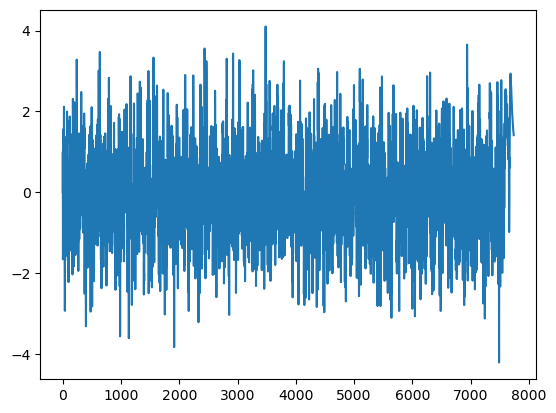

In [320]:
plt.plot(features_.values)

In [315]:
features_

,ECOG_R_4_SMC_AT-avgref_bandpass_activity_high beta
0,0.000000
1,-1.000000
2,-1.362449
3,-0.860693
4,0.130098
...,...
8082,1.497367
8083,1.486639
8084,1.467720
8085,1.447067


In [306]:
settings_

{'BIDS_path': 'C:\\Users\\richa\\OneDrive - Charité - Universitätsmedizin Berlin\\Berlin_ECOG_LFP_derivatives\\pipeline-MotOnsetPred_2021-04-26',
 'out_path': 'C:\\Users\\richa\\OneDrive - Charité - Universitätsmedizin Berlin\\Berlin_ECOG_LFP_derivatives\\pipeline-MotOnsetPred_2021-04-26\\derivatives',
 'sampling_rate_features': 10,
 'methods': {'raw_resampling': True,
  'raw_normalization': True,
  'feature_normalization': True,
  'kalman_filter': False,
  'add_channels': False,
  're_referencing': True,
  'notch_filter': True,
  'bandpass_filter': True,
  'raw_hjorth': True,
  'sharpwave_analysis': False,
  'return_raw': True,
  'project_cortex': False,
  'project_subcortex': False,
  'pdc': False,
  'dtf': False},
 'raw_resampling_settings': {'resample_freq': 1000},
 'raw_normalization_settings': {'normalization_time': 10,
  'normalization_method': 'zscore',
  'clip': 3},
 'feature_normalization_settings': {'normalization_time': 10,
  'normalization_method': 'zscore',
  'clip': 3},


In [29]:
files

['C:\\Users\\richa\\OneDrive - Charité - Universitätsmedizin Berlin\\Berlin_ECOG_LFP_derivatives\\pipeline-MotOnsetPred_2021-04-26\\derivatives\\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\\sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_FEATURES.csv',
 'C:\\Users\\richa\\OneDrive - Charité - Universitätsmedizin Berlin\\Berlin_ECOG_LFP_derivatives\\pipeline-MotOnsetPred_2021-04-26\\derivatives\\sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\\sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_FEATURES.csv',
 'C:\\Users\\richa\\OneDrive - Charité - Universitätsmedizin Berlin\\Berlin_ECOG_LFP_derivatives\\pipeline-MotOnsetPred_2021-04-26\\derivatives\\sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg\\sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg_FEATURES.csv',
 'C:\\Users\\richa\\OneDrive - Charité - Universitätsmedizin Berlin\\Berl

# Test additional temporal features

In [7]:
deriv_root = r'C:\Users\richa\OneDrive - Charité - Universitätsmedizin Berlin\Berlin_ECOG_LFP_derivatives\pipeline-MotOnsetPred_2021-04-26\derivatives\feat_no_norm'
nm_reader = NM_reader.NM_Reader(deriv_root)
feature_list = nm_reader.get_feature_list()
print(*feature_list, sep='\n')

sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg
sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-003_ses-EphysMedOn03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg
sub-005_ses-EphysMedOff02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg
sub-005_ses-EphysMedOff02_task-SelfpacedRot

In [28]:
### MOTOR ONSET ###
mov_begin = -1.
mov_end = 0.
###################
contralateral = [
    'sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    #'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg',
    'sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOff02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg'
    #'sub-005_ses-EphysMedOn02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg'
]
ipsilateral = [
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg'
    #'sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg'
]
runs = {"Contralateral": contralateral, "Ipsilateral": ipsilateral}
for name, run in runs.items():
    run_list = list() 
    for feature_file in run:
        print(feature_file)
        features_ = nm_reader.read_features(feature_file)
        settings_ = nm_reader.read_settings(feature_file)
        channels_ = np.array(settings_['ch_names'])[settings_['feature_idx']]
        label_ = nm_reader.read_label('rota_squared')
        dat_label_ = label_.values
        diff_ = np.zeros_like(dat_label_, dtype=int)
        diff_[1:] = np.diff(dat_label_)
        events_ = np.nonzero(diff_)[0]
        feat_picks = ['bandpass_activity_theta', 'bandpass_activity_alpha', 
                      'bandpass_activity_low beta', 'bandpass_activity_high beta', 
                      'bandpass_activity_low gamma', 'bandpass_activity_high gamma']
        column_picks = [
            col for col in features_.columns if any([pick in col for pick in feat_picks])]
        features_ = features_[column_picks]
        feat_list = list()
        feat_list.append(features_)
        for s in np.arange(1, 10):
            feat_list.append(features_.shift(s, axis=0))
        for i in np.arange(1, len(feat_list) + 1):
            features_ = pd.concat(feat_list[:i], axis=1)
            features_ = features_.fillna(0.)
            out_name = feature_file + '_mot_onset_sLDA_results_' + str(i * 100) + 'ms.tsv'
            out_path = os.path.join(deriv_root, feature_file, out_name)
            init_classification(
                features_, events_, channels_, mov_begin, mov_end, out_path)

sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg


KeyboardInterrupt: 

In [27]:
from numpy import mean
import pandas as pd

from imblearn.over_sampling import RandomOverSampler 
from sklearn.metrics import (accuracy_score, average_precision_score,
                             balanced_accuracy_score)
from sklearn.utils import resample

def balance_samples(data, target, method='oversample'):
    """"""
    if method == 'oversample':
        ros = RandomOverSampler(sampling_strategy='auto')
    elif method == 'undersample':
        ros = RandomUnderSampler(sampling_strategy='auto')  
    else:
        print(f"Method not identified. Given method was {method}.")
    data, target = ros.fit_resample(data, target)
    return data, target

def get_class_scores(X_, y_, cross_val_, classifier_, groups_):
    """"""
    accuracy_list = list()
    average_precision_list = list()
    for train, test in cross_val_.split(X_, y_, groups_):
        X_train = X_[train]
        y_train = y_[train]
        if mean(y_train) != 0.5:
            X_train, y_train = balance_samples(X_train, y_train, 'oversample')
        X_test = X_[test]
        y_test = y_[test]
        #print('Number of samples:', X_train.shape[0], 'Number of features:', X_train.shape[1])
        #print("y_test:", mean(y_test), "y_train:", mean(y_train))
        classifier_.fit(X_train, y_train)
        y_pred = classifier_.predict(X_test)
        y_score = classifier_.decision_function(X_test)
        accuracy_list.append(balanced_accuracy_score(y_test, y_pred))
        average_precision_list.append(average_precision_score(y_test, y_score))
    return mean(accuracy_list), mean(average_precision_list)

In [24]:
def init_classification(
    features, events, ch_names, movement_begin, movement_end, out_file):
    """"""
    scores_list = list()
    distance_onset = 2.
    distance_end = 0. if feature_file == 'sub-FOG006_ses-EphysMedOn_task-ButtonPress_acq-StimOff_run-01_ieeg' else 2.
    for ch_name in ch_names:
        AP, accuracy = classify_lda(
            features, events, ch_name, movement_begin, movement_end, 
            distance_onset, distance_end, verbose=False)
        scores_list.append([AP, accuracy])
    curr_df = pd.DataFrame(data=scores_list, index=ch_names, 
                           columns=['average_precision', 'accuracy'])
    curr_df.to_csv(out_file, sep='\t')

In [18]:
### MOVEMENT ###
mov_begin = 0.
mov_end = 1.
###################
contralateral = [
    'sub-002_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    #'sub-002_ses-EphysMedOff03_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg',
    'sub-003_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOff02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg'
    #'sub-005_ses-EphysMedOn02_task-SelfpacedRotationL_acq-StimOn_run-01_ieeg'
]
ipsilateral = [
    'sub-004_ses-EphysMedOff01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-004_ses-EphysMedOn01_task-SelfpacedRotationL_acq-StimOff_run-01_ieeg',
    'sub-005_ses-EphysMedOff01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg',
    #'sub-005_ses-EphysMedOff02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg',
    'sub-005_ses-EphysMedOn01_task-SelfpacedRotationR_acq-StimOff_run-01_ieeg'
    #'sub-005_ses-EphysMedOn02_task-SelfpacedRotationR_acq-StimOn_run-01_ieeg'
]
runs = {"Contralateral": contralateral, "Ipsilateral": ipsilateral}

for name, run in runs.items():
    run_list = list() 
    for feature_file in run:
        print(feature_file)
        features_ = nm_reader.read_features(feature_file)
        settings_ = nm_reader.read_settings(feature_file)
        channels_ = np.array(settings_['ch_names'])[settings_['feature_idx']]
        label_ = nm_reader.read_label('rota_squared')
        feat_picks = ['bandpass_activity_theta', 'bandpass_activity_alpha', 
                   'bandpass_activity_low beta', 'bandpass_activity_high beta', 
                   'bandpass_activity_low gamma', 'bandpass_activity_high gamma']
        ecog_picks = ['ECOG']
        lfp_picks = ['LFP']
        column_picks = [col for col in features_.columns if any([pick in col for pick in feat_picks])]
        features_ = features_[column_picks]
        features_diff_ = features_.diff(axis=0).fillna(0.)
        features_diff_ = features_diff_.add_suffix('_diff')
        features_ = pd.concat((features_, features_diff_), axis=1)
        dat_label_ = label_.values
        diff_ = np.zeros_like(dat_label_, dtype=int)
        diff_[1:] = np.diff(dat_label_)
        events_ = np.nonzero(diff_)[0]
        ecog_chs = [ch for ch in channels if 'ECOG' in ch]
        lfp_chs = [ch for ch in channels if 'LFP' in ch]
        chs = ecog_chs + lfp_chs
        curr_list = list()
        ecog_list = list()
        for ch in ecog_chs:
            AP, accuracy = classify_lda(features_, events_, ch, 
                                        mov_begin, mov_end, True)
            ecog_list.append([AP, accuracy])
            curr_list.append([AP, accuracy]) 
        lfp_list = list()    
        for ch in lfp_chs:
            AP, accuracy = classify_lda(features_, events_, ch, 
                                        mov_begin, mov_end, True)
            lfp_list.append([AP, accuracy])
            curr_list.append([AP, accuracy])
        # Now select best performance by best accuracy: "1"
        lfp_max = max_val(lfp_list, 1)[0]
        ecog_max = max_val(ecog_list, 1)[0]
        run_list.append([lfp_chs[lfp_max]] + lfp_list[lfp_max]
                        + [ecog_chs[ecog_max]] + ecog_list[ecog_max])
        curr_df = pd.DataFrame(data=curr_list, index=lfp_chs + ecog_chs, 
                               columns=['average_precision', 'accuracy'])
        out_file = os.path.join(deriv_root, feature_file, 
                                feature_file + '_mot_onset_accuracy_AP' +'' +''.tsv')
        curr_df.to_csv(out_file, sep='\t')
    run_df = pd.DataFrame(
        data=run_list, index=run, 
        columns=['LFP_best_ch', 'LFP_best_average_precision', 'LFP_best_accuracy', 
                 'ECOG_best_ch', 'ECOG_best_average_precision', 'ECOG_best_accuracy'])
    out_file_run = os.path.join(deriv_root, name+'_movement_group.tsv')
    run_df.to_csv(out_file_run, sep='\t')

SyntaxError: EOL while scanning string literal (<ipython-input-18-deac15d62170>, line 74)